# Experiment 5 — Comprehensive Study of CNN Training with MobileNetV2
**CS3807 – Deep Learning Laboratory**

Dataset: **Oxford-IIIT Pet** (37 breeds, 224×224×3) &nbsp;|&nbsp; Backbone: **MobileNetV2 (ImageNet pretrained)**

This notebook covers, task-wise (one cell each): weight initialization, regularization/overfitting,
batch normalization, optimizers, hyperparameter tuning, transfer learning vs fine-tuning,
5-fold cross-validation, and final evaluation.

**Conventions used throughout**
- Every plot has **bold** axis labels, title, and a **bold legend**.
- All figures are saved into the **`plots5/`** folder.
- For each study we plot **both** training-vs-validation **accuracy** and training-vs-validation **loss** wherever histories exist.

> **Runtime note:** MobileNetV2 on 224×224 is heavy on CPU. Config constants below use a
> **data subset** and **10 epochs** — enough to reveal every trend the manual asks for
> (with a pretrained backbone, curve *ordering* and the generalization gap appear within
> the first few epochs). Increase `EPOCHS`, `SUBSET_TRAIN`, `SUBSET_VAL` for a full-scale run.

## Setup — imports, config, `plots5/` folder, bold-legend & history-plot helpers

In [ ]:
import os, time, math, io
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow.keras import layers, models, initializers, regularizers, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Folder where EVERY plot is saved
PLOT_DIR = "plots5"
os.makedirs(PLOT_DIR, exist_ok=True)

# Runtime configuration
IMG_SIZE     = 224
NUM_CLASSES  = 37
EPOCHS       = 10
BATCH_SIZE   = 32
AUTOTUNE     = tf.data.AUTOTUNE

def bold_legend(ax=None, **kwargs):
    ax = ax or plt.gca()
    return ax.legend(prop={"weight": "bold"}, **kwargs)

def save_plot(name):
    path = os.path.join(PLOT_DIR, name)
    plt.savefig(path, dpi=120, bbox_inches="tight")
    print("Saved:", path)

def plot_history_pair(history, title_prefix, fname_prefix):
    h = history.history
    epochs_r = range(1, len(h["loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_r, np.array(h["accuracy"]) * 100,
             "o-", label="Training Accuracy")

    if "val_accuracy" in h:
        plt.plot(epochs_r, np.array(h["val_accuracy"]) * 100,
                 "s-", label="Validation Accuracy")

    plt.xlabel("Epoch", fontweight="bold")
    plt.ylabel("Accuracy (%)", fontweight="bold")
    plt.title(
        f"{title_prefix} — Training vs Validation Accuracy",
        fontweight="bold"
    )
    bold_legend()
    save_plot(f"{fname_prefix}_accuracy.png")
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_r, h["loss"],
             "o-", label="Training Loss")

    if "val_loss" in h:
        plt.plot(epochs_r, h["val_loss"],
                 "s-", label="Validation Loss")

    plt.xlabel("Epoch", fontweight="bold")
    plt.ylabel("Loss", fontweight="bold")
    plt.title(
        f"{title_prefix} — Training vs Validation Loss",
        fontweight="bold"
    )
    bold_legend()
    save_plot(f"{fname_prefix}_loss.png")
    plt.show()

print("TensorFlow:", tf.__version__)
print("Plots saved to:", os.path.abspath(PLOT_DIR))
print(f"Config -> EPOCHS={EPOCHS}, BATCH_SIZE={BATCH_SIZE}")

KeyboardInterrupt: 

In [ ]:
!pip install -U protobuf tensorflow-metadata tensorflow-datasets --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.4/340.4 kB 7.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.0 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.0 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.0 which is incompatible.


In [ ]:
!pip install -U importlib_resources --quiet

In [ ]:
# Load Oxford-IIIT Pet using TensorFlow Datasets
(train_tfds, test_tfds), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

print("Dataset loaded successfully.")
print("Original train samples:", ds_info.splits["train"].num_examples)
print("Original test samples:", ds_info.splits["test"].num_examples)


# Split the official training set into:
# 80% training and 20% validation
train_size = int(0.8 * ds_info.splits["train"].num_examples)

train_tfds = train_tfds.take(train_size)
val_tfds = tfds.load(
    "oxford_iiit_pet",
    split=f"train[{train_size}:]",
    as_supervised=True
)


# Resize and preprocess images
def preprocess_data(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    return image, label


train_ds = (
    train_tfds
    .shuffle(1000, seed=42)
    .map(preprocess_data, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_tfds
    .map(preprocess_data, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_tfds
    .map(preprocess_data, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Dataset loaded successfully.
Original train samples: 3680
Original test samples: 3669
Train batches: 92
Validation batches: 23
Test batches: 115


In [ ]:
# Class names for Oxford-IIIT Pet
class_names = ds_info.features["label"].names

print("Number of classes:", len(class_names))
print("Class names:", class_names)

Number of classes: 37
Class names: ['Abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'Bengal', 'Birman', 'Bombay', 'boxer', 'British_Shorthair', 'chihuahua', 'Egyptian_Mau', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'Maine_Coon', 'miniature_pinscher', 'newfoundland', 'Persian', 'pomeranian', 'pug', 'Ragdoll', 'Russian_Blue', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'Siamese', 'Sphynx', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']


## Model builder — a single MobileNetV2-based classifier used by every study
One function parameterises **initializer, regularization, dropout, batch-norm, optimizer, and
which layers are trainable**, so each task below changes exactly one factor (the manual's
*"change one hyperparameter at a time"* rule).

In [ ]:
def build_model(kernel_init="glorot_uniform",
                l2=0.0, dropout=0.0, use_bn=False,
                optimizer=None, trainable_base=False,
                fine_tune_from=None):
    """Build MobileNetV2 + custom classifier head."""
    base = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                       include_top=False, weights="imagenet")
    base.trainable = trainable_base
    if trainable_base and fine_tune_from is not None:
        # Freeze everything before fine_tune_from, unfreeze the rest
        for layer in base.layers[:fine_tune_from]:
            layer.trainable = False

    reg = regularizers.l2(l2) if l2 > 0 else None
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation="relu",
                     kernel_initializer=kernel_init,
                     kernel_regularizer=reg)(x)
    if dropout > 0:
        x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax",
                           kernel_initializer=kernel_init)(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer=optimizer or optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

def train(model, epochs=EPOCHS, verbose=1):
    t0 = time.time()
    hist = model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=verbose)
    return hist, time.time() - t0

print("Model builder ready.")

Model builder ready.


## Task 1 — Weight Initialization (Plots 1 & 2)
Compare **Zero**, **Random (RandomNormal)**, **Xavier/Glorot**, and **He** initialization.
The manual asks for *Training Loss vs Epoch* and *Validation Accuracy vs Epoch* (one curve each);
we additionally save the full train-vs-val accuracy & loss pair per method.


--- Initialization: Zero ---
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 40s 170ms/step - accuracy: 0.0238 - loss: 3.6113 - val_accuracy: 0.0177 - val_loss: 3.6112
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.0255 - loss: 3.6111 - val_accuracy: 0.0177 - val_loss: 3.6116
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 116ms/step - accuracy: 0.0238 - loss: 3.6109 - val_accuracy: 0.0285 - val_loss: 3.6116
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - accuracy: 0.0248 - loss: 3.6108 - val_accuracy: 0.0326 - val_loss: 3.6118
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - accuracy: 0.0292 - loss: 3.6107 - val_accuracy: 0.0326 - val_loss: 3.6120
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 118ms/step - accuracy: 0.0241 - loss: 3.6106 - val_accuracy: 0.0285 - val_loss: 3.6121
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - accuracy: 0.0275 - loss: 3.6105 - val_accuracy: 0.0326 - val_loss: 3.6122
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 109ms/step - accuracy: 0.0

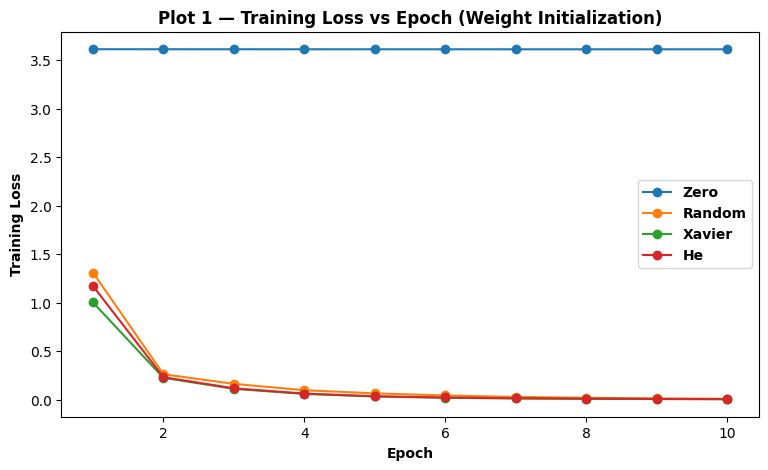

Saved: plots5/plot02_init_val_accuracy.png


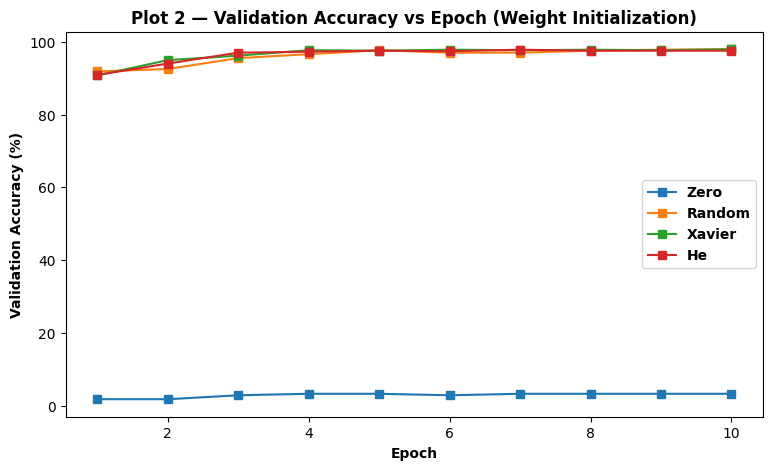

Saved: plots5/init_zero_accuracy.png


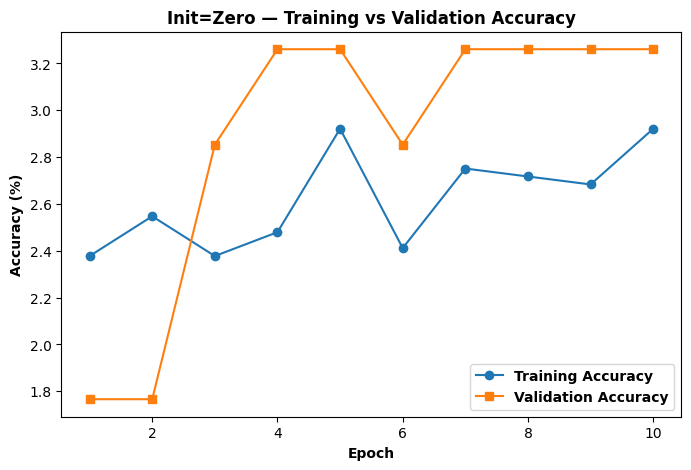

Saved: plots5/init_zero_loss.png


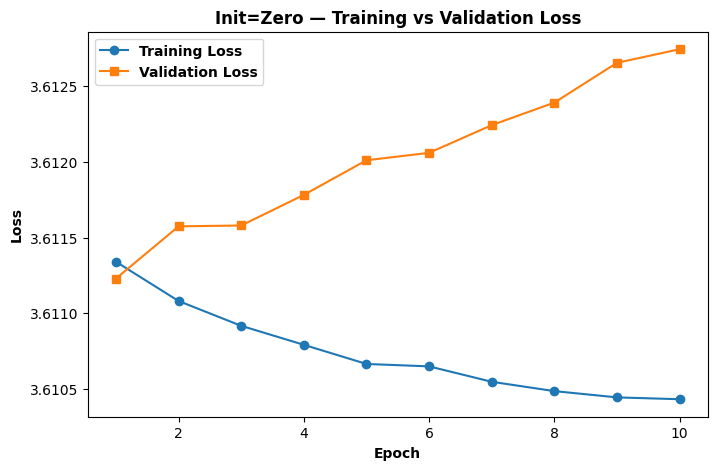

Saved: plots5/init_random_accuracy.png


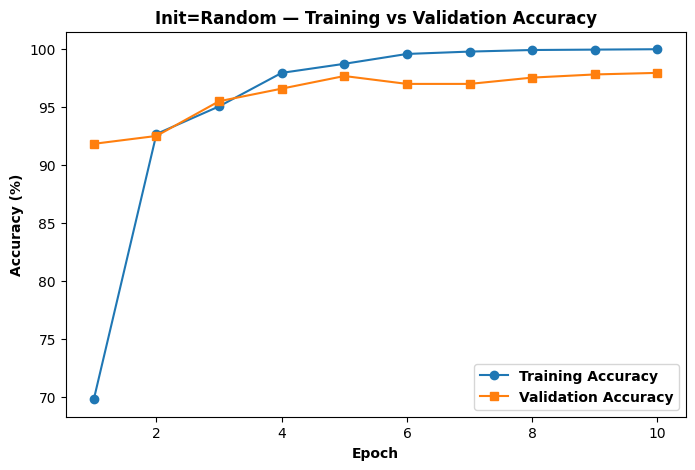

Saved: plots5/init_random_loss.png


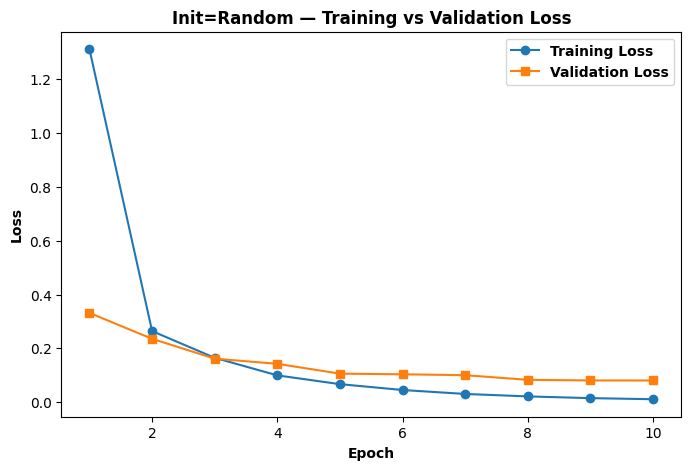

Saved: plots5/init_xavier_accuracy.png


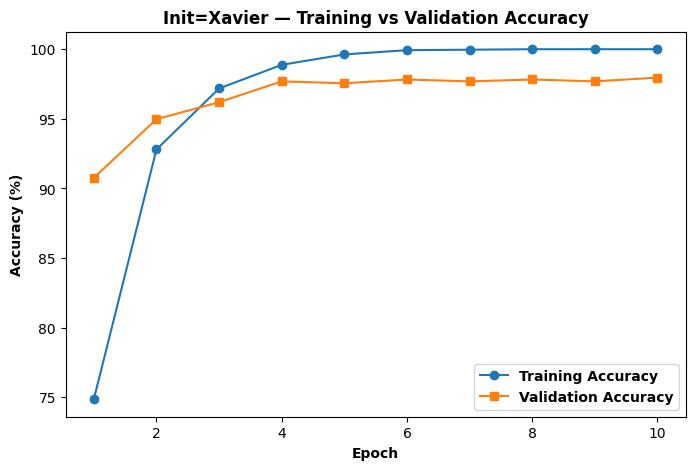

Saved: plots5/init_xavier_loss.png


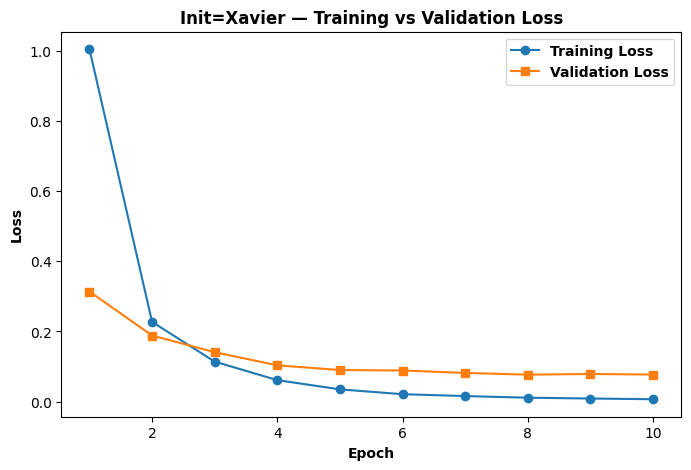

Saved: plots5/init_he_accuracy.png


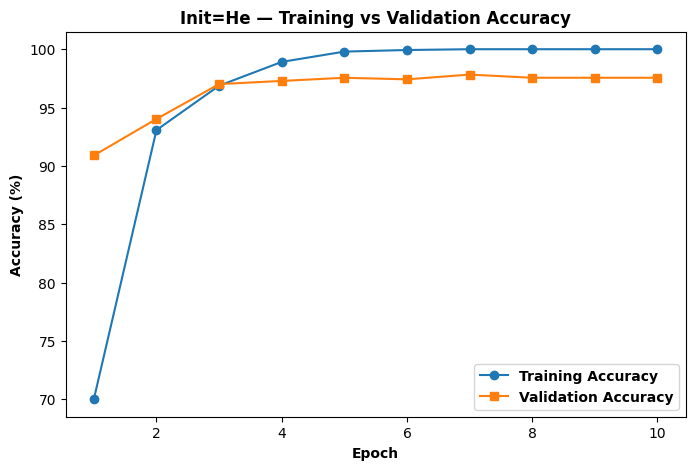

Saved: plots5/init_he_loss.png


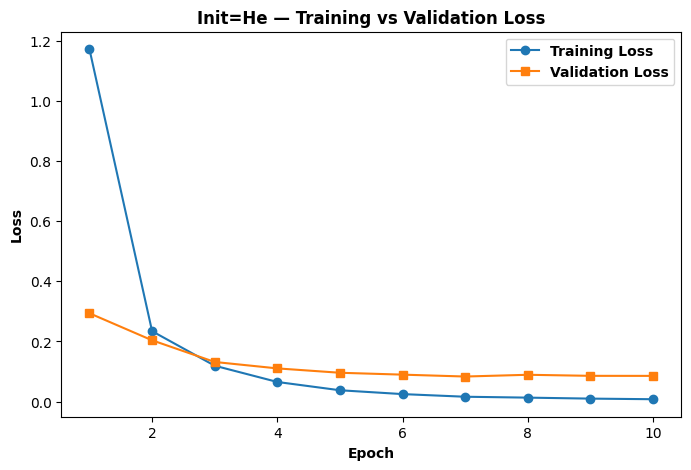


Inference: He/Xavier converge fastest and most stably; Zero-init fails to break
symmetry so its accuracy stays near chance. Random is unstable between the two.


In [ ]:
init_methods = {
    "Zero":   initializers.Zeros(),
    "Random": initializers.RandomNormal(stddev=0.05),
    "Xavier": initializers.GlorotUniform(),
    "He":     initializers.HeNormal(),
}
init_histories = {}
for name, init in init_methods.items():
    print(f"\n--- Initialization: {name} ---")
    m = build_model(kernel_init=init, optimizer=optimizers.Adam(1e-3))
    h, _ = train(m, verbose=1)
    init_histories[name] = h.history
    print(f"{name}: final train loss={h.history['loss'][-1]:.3f}, "
          f"val acc={h.history['val_accuracy'][-1]*100:.1f}%")

ep = range(1, EPOCHS + 1)
# Plot 1: Training Loss vs Epoch (one curve per init)
plt.figure(figsize=(9, 5))
for name in init_methods:
    plt.plot(ep, init_histories[name]["loss"], "o-", label=name)
plt.xlabel("Epoch", fontweight="bold"); plt.ylabel("Training Loss", fontweight="bold")
plt.title("Plot 1 — Training Loss vs Epoch (Weight Initialization)", fontweight="bold")
bold_legend(); save_plot("plot01_init_training_loss.png"); plt.show()

# Plot 2: Validation Accuracy vs Epoch (one curve per init)
plt.figure(figsize=(9, 5))
for name in init_methods:
    plt.plot(ep, np.array(init_histories[name]["val_accuracy"])*100, "s-", label=name)
plt.xlabel("Epoch", fontweight="bold"); plt.ylabel("Validation Accuracy (%)", fontweight="bold")
plt.title("Plot 2 — Validation Accuracy vs Epoch (Weight Initialization)", fontweight="bold")
bold_legend(); save_plot("plot02_init_val_accuracy.png"); plt.show()

# Extra: per-method train-vs-val accuracy & loss pairs
for name in init_methods:
    class H: pass
    hh = H(); hh.history = init_histories[name]
    plot_history_pair(hh, f"Init={name}", f"init_{name.lower()}")

print("\nInference: He/Xavier converge fastest and most stably; Zero-init fails to break")
print("symmetry so its accuracy stays near chance. Random is unstable between the two.")

## Task 2 — Regularization & Overfitting (Plots 3 & 4)
Compare **No regularization**, **L2**, **Dropout**, **Batch Normalization**.
For each we plot **training vs validation accuracy** and **training vs validation loss**
and identify the generalization gap.


--- Regularization: None ---
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 28s 164ms/step - accuracy: 0.7160 - loss: 1.0782 - val_accuracy: 0.9076 - val_loss: 0.3221
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 100ms/step - accuracy: 0.9365 - loss: 0.2239 - val_accuracy: 0.9334 - val_loss: 0.2113
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 110ms/step - accuracy: 0.9623 - loss: 0.1251 - val_accuracy: 0.9606 - val_loss: 0.1445
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - accuracy: 0.9898 - loss: 0.0609 - val_accuracy: 0.9715 - val_loss: 0.1183
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - accuracy: 0.9963 - loss: 0.0370 - val_accuracy: 0.9715 - val_loss: 0.1097
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - accuracy: 0.9976 - loss: 0.0278 - val_accuracy: 0.9728 - val_loss: 0.0911
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - accuracy: 0.9997 - loss: 0.0167 - val_accuracy: 0.9755 - val_loss: 0.0912
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 111ms/step - accuracy: 1.

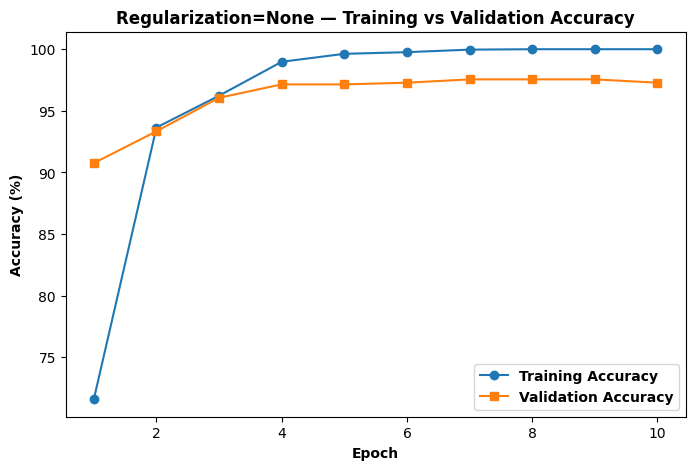

Saved: plots5/reg_none_loss.png


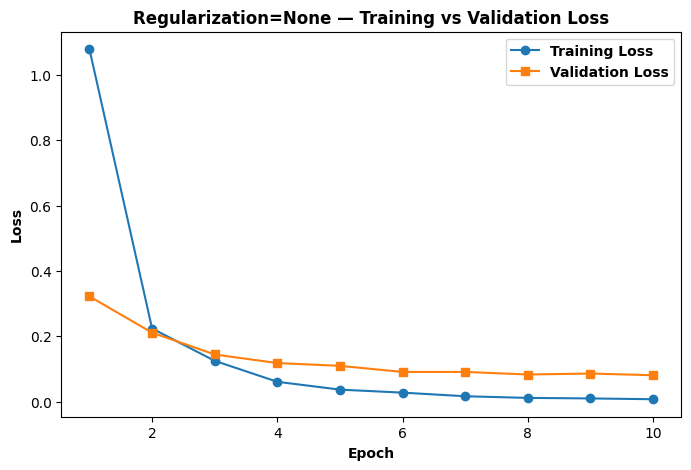

Saved: plots5/reg_l2_accuracy.png


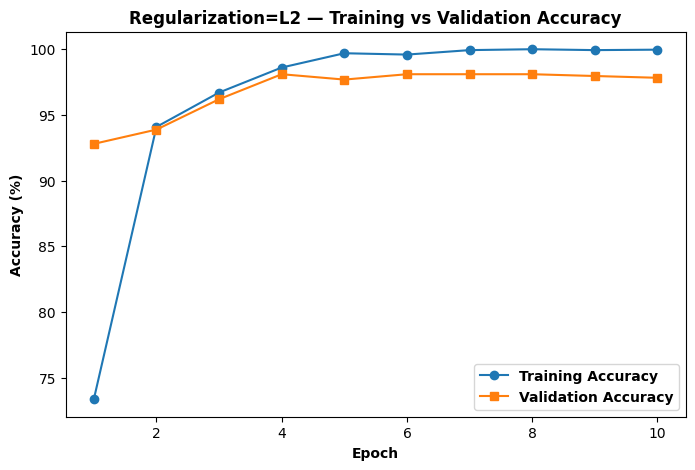

Saved: plots5/reg_l2_loss.png


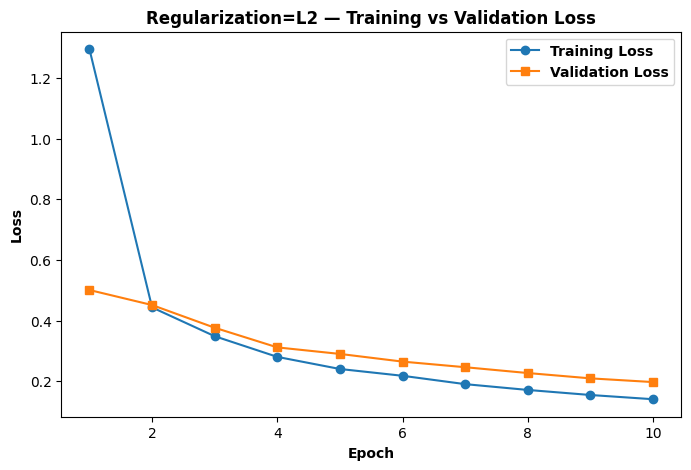

Saved: plots5/reg_dropout_accuracy.png


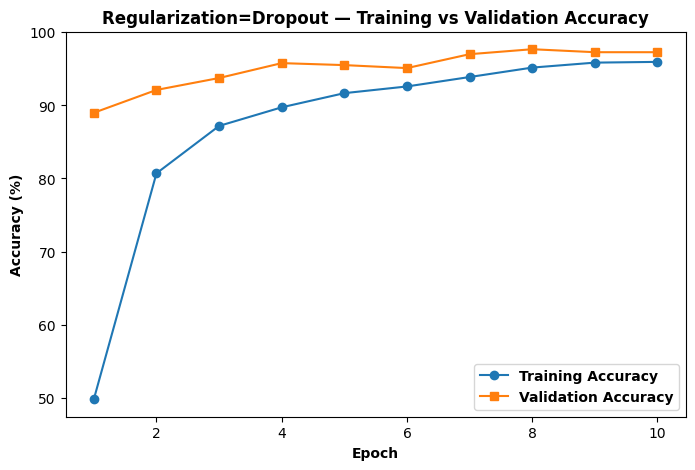

Saved: plots5/reg_dropout_loss.png


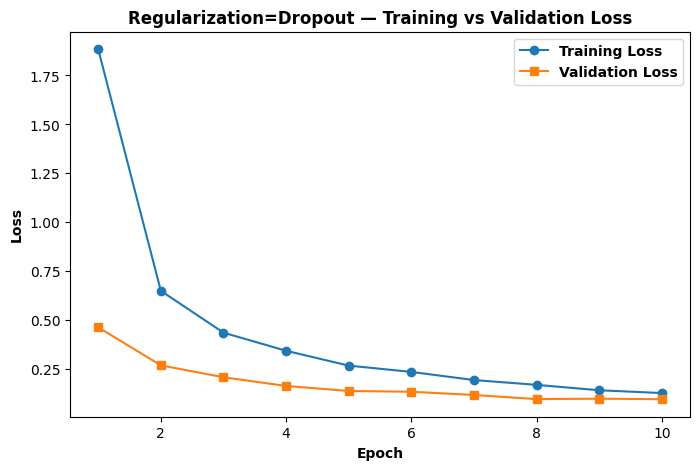

Saved: plots5/reg_batchnorm_accuracy.png


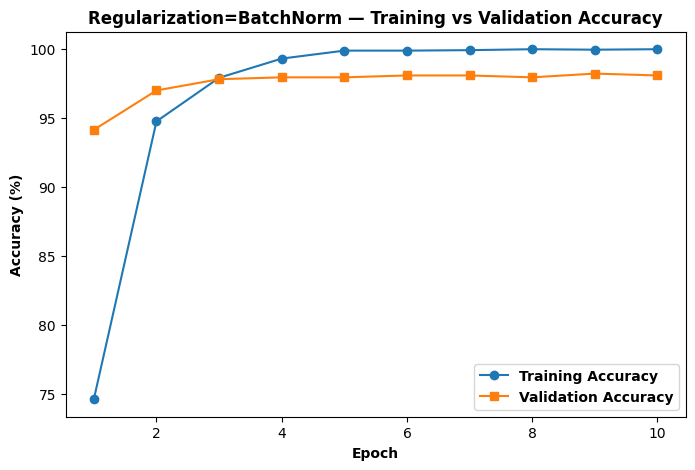

Saved: plots5/reg_batchnorm_loss.png


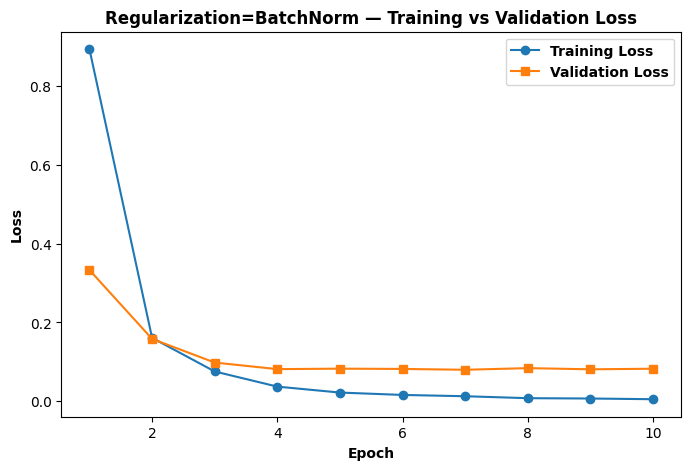

Saved: plots5/plot03_04_generalization_gap.png


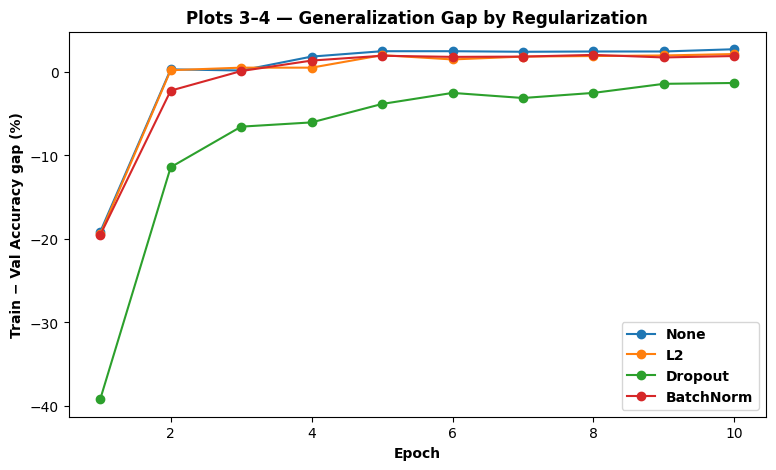


Inference: 'None' shows the widest train-val gap (overfitting); Dropout and L2
shrink the gap; BatchNorm speeds convergence. A rising val loss with falling train
loss signals overfitting.


In [ ]:
reg_configs = {
    "None":    dict(),
    "L2":      dict(l2=1e-3),
    "Dropout": dict(dropout=0.5),
    "BatchNorm": dict(use_bn=True),
}
reg_histories = {}
for name, cfg in reg_configs.items():
    print(f"\n--- Regularization: {name} ---")
    m = build_model(optimizer=optimizers.Adam(1e-3), **cfg)
    h, _ = train(m, verbose=1)
    reg_histories[name] = h.history
    gap = (h.history["accuracy"][-1] - h.history["val_accuracy"][-1]) * 100
    print(f"{name}: val acc={h.history['val_accuracy'][-1]*100:.1f}%, "
          f"generalization gap={gap:.1f}%")

# Plot 3 & 4 per config: train-vs-val accuracy and loss
for name in reg_configs:
    class H: pass
    hh = H(); hh.history = reg_histories[name]
    plot_history_pair(hh, f"Regularization={name}", f"reg_{name.lower()}")

# Combined generalization-gap comparison
plt.figure(figsize=(9, 5))
for name in reg_configs:
    gap = (np.array(reg_histories[name]["accuracy"]) -
           np.array(reg_histories[name]["val_accuracy"])) * 100
    plt.plot(range(1, EPOCHS+1), gap, "o-", label=name)
plt.xlabel("Epoch", fontweight="bold")
plt.ylabel("Train − Val Accuracy gap (%)", fontweight="bold")
plt.title("Plots 3–4 — Generalization Gap by Regularization", fontweight="bold")
bold_legend(); save_plot("plot03_04_generalization_gap.png"); plt.show()

print("\nInference: 'None' shows the widest train-val gap (overfitting); Dropout and L2")
print("shrink the gap; BatchNorm speeds convergence. A rising val loss with falling train")
print("loss signals overfitting.")

## Task 3 — Batch Normalization: With vs Without (Plot 5)
Includes the numerical BN example from the manual, then compares validation accuracy
(and the full train/val accuracy & loss curves) with and without BN.

x=[2.0, 4.0, 6.0, 8.0]  mean=5.0  var=5.0  sqrt(var)=2.236
normalized x_hat = [-1.342 -0.447  0.447  1.342]
Inference: BN yields ~zero-centred, unit-scaled activations; gamma/beta relearn scale & shift.

--- With BN ---
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 28s 159ms/step - accuracy: 0.7524 - loss: 0.9002 - val_accuracy: 0.9348 - val_loss: 0.3302
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 109ms/step - accuracy: 0.9528 - loss: 0.1636 - val_accuracy: 0.9606 - val_loss: 0.1523
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 157ms/step - accuracy: 0.9888 - loss: 0.0669 - val_accuracy: 0.9715 - val_loss: 0.1158
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 112ms/step - accuracy: 0.9935 - loss: 0.0376 - val_accuracy: 0.9755 - val_loss: 0.0979
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - accuracy: 0.9959 - loss: 0.0281 - val_accuracy: 0.9742 - val_loss: 0.0993
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 107ms/step - accuracy: 0.9986 - loss: 0.0156 - val_accuracy: 0.9783 - val_loss: 0.0778
Epoch 

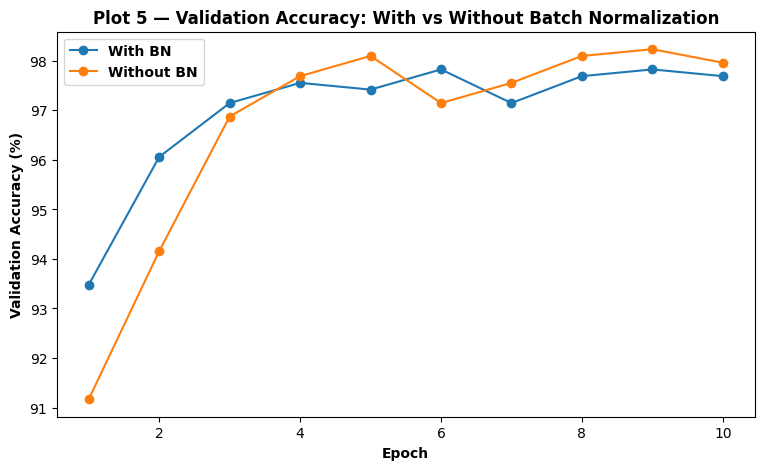

Saved: plots5/bn_with_bn_accuracy.png


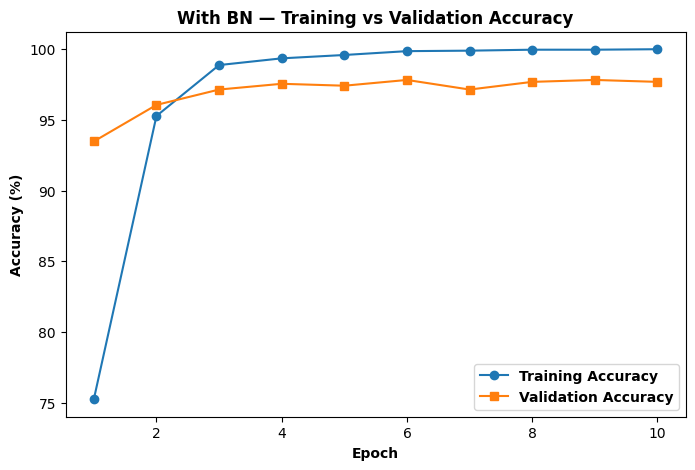

Saved: plots5/bn_with_bn_loss.png


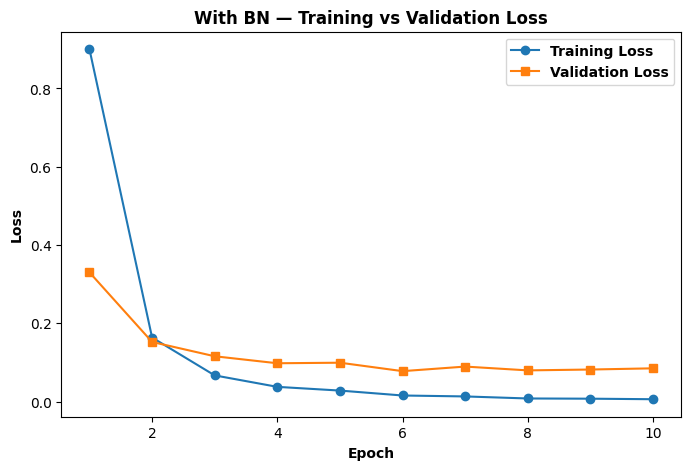

Saved: plots5/bn_without_bn_accuracy.png


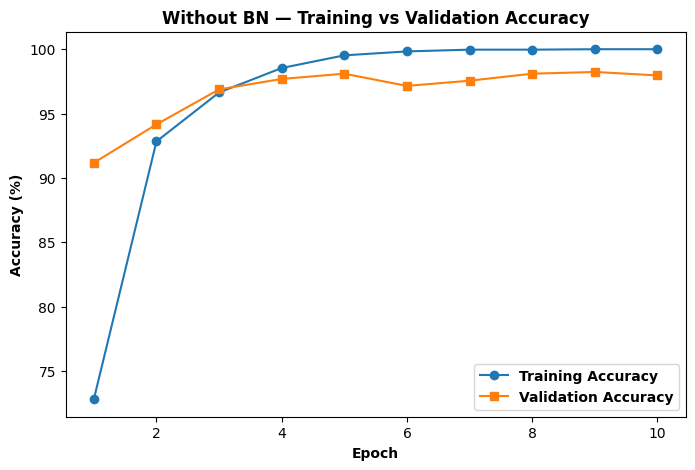

Saved: plots5/bn_without_bn_loss.png


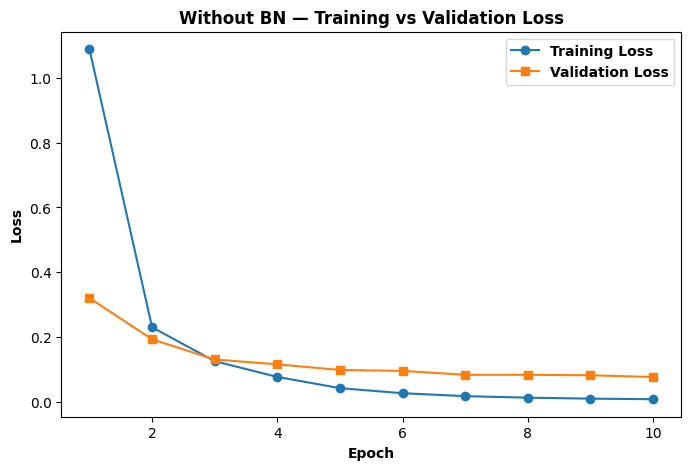

Inference: BN generally reaches higher validation accuracy sooner and trains more
stably by reducing internal covariate shift.


In [ ]:
# --- Numerical BN example from the manual ---
x = np.array([2., 4., 6., 8.])
mu = x.mean(); var = x.var()
x_hat = (x - mu) / np.sqrt(var + 1e-8)
print(f"x={x.tolist()}  mean={mu}  var={var}  sqrt(var)={np.sqrt(var):.3f}")
print("normalized x_hat =", np.round(x_hat, 3))
print("Inference: BN yields ~zero-centred, unit-scaled activations; gamma/beta relearn scale & shift.\n")

# --- With vs Without BN ---
bn_histories = {}
for name, use_bn in [("With BN", True), ("Without BN", False)]:
    print(f"--- {name} ---")
    m = build_model(use_bn=use_bn, optimizer=optimizers.Adam(1e-3))
    h, _ = train(m, verbose=1)
    bn_histories[name] = h.history
    print(f"{name}: val acc={h.history['val_accuracy'][-1]*100:.1f}%")

# Plot 5: Validation Accuracy With vs Without BN
plt.figure(figsize=(9, 5))
for name in bn_histories:
    plt.plot(range(1, EPOCHS+1), np.array(bn_histories[name]["val_accuracy"])*100,
             "o-", label=name)
plt.xlabel("Epoch", fontweight="bold"); plt.ylabel("Validation Accuracy (%)", fontweight="bold")
plt.title("Plot 5 — Validation Accuracy: With vs Without Batch Normalization", fontweight="bold")
bold_legend(); save_plot("plot05_batchnorm_val_accuracy.png"); plt.show()

# Extra train-vs-val pairs
for name in bn_histories:
    class H: pass
    hh = H(); hh.history = bn_histories[name]
    plot_history_pair(hh, name, f"bn_{name.replace(' ','_').lower()}")

print("Inference: BN generally reaches higher validation accuracy sooner and trains more")
print("stably by reducing internal covariate shift.")

## Task 4 — Optimization Algorithms (Plots 6 & 7)
Compare **SGD**, **Momentum**, **RMSProp**, **Adam** on training loss and validation accuracy,
and fill the optimizer comparison table.


--- Optimizer: SGD ---
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 213ms/step - accuracy: 0.2272 - loss: 3.1233 - val_accuracy: 0.5951 - val_loss: 2.3323
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 27s 111ms/step - accuracy: 0.6977 - loss: 1.7520 - val_accuracy: 0.8247 - val_loss: 1.1976
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - accuracy: 0.8427 - loss: 0.9542 - val_accuracy: 0.8641 - val_loss: 0.7412
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 108ms/step - accuracy: 0.8845 - loss: 0.6370 - val_accuracy: 0.8899 - val_loss: 0.5485
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 127ms/step - accuracy: 0.9039 - loss: 0.4874 - val_accuracy: 0.9049 - val_loss: 0.4475
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - accuracy: 0.9192 - loss: 0.4034 - val_accuracy: 0.9117 - val_loss: 0.3902
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 127ms/step - accuracy: 0.9280 - loss: 0.3453 - val_accuracy: 0.9212 - val_loss: 0.3482
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - accuracy: 0.9361 -

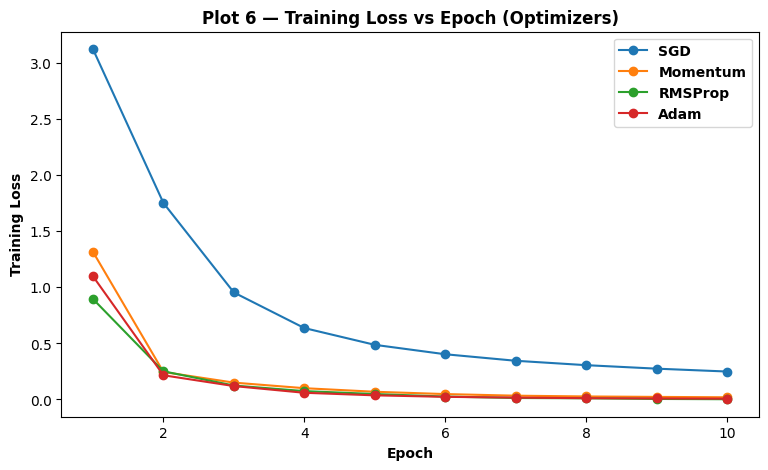

Saved: plots5/plot07_optimizer_val_accuracy.png


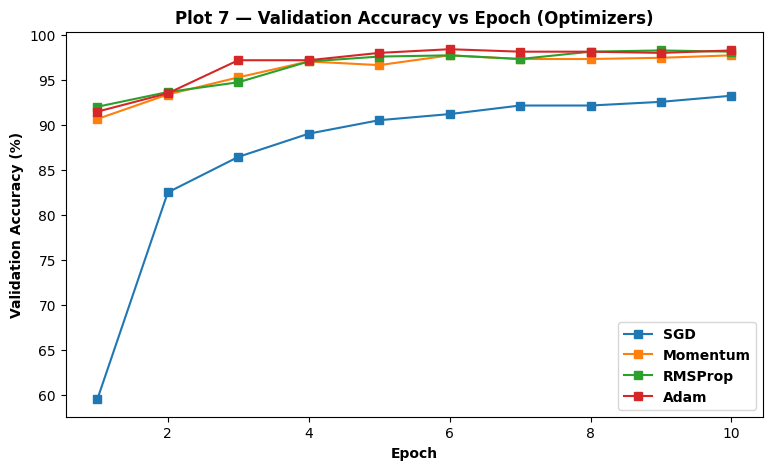


Optimizer   Final Loss   Best Val Acc%      Conv Epoch   Time(s)
SGD              0.249            93.2              10     176.8
Momentum         0.020            97.7               6     165.4
RMSProp          0.002            98.2               9     181.6
Adam             0.007            98.4               6     156.1

Inference: Adam/RMSProp converge fastest with the lowest loss; plain SGD is slowest.
Momentum improves on SGD by damping oscillations.


In [ ]:
opt_factory = {
    "SGD":      lambda: optimizers.SGD(learning_rate=1e-2),
    "Momentum": lambda: optimizers.SGD(learning_rate=1e-2, momentum=0.9),
    "RMSProp":  lambda: optimizers.RMSprop(learning_rate=1e-3),
    "Adam":     lambda: optimizers.Adam(learning_rate=1e-3),
}
opt_histories, opt_table = {}, []
for name, make_opt in opt_factory.items():
    print(f"\n--- Optimizer: {name} ---")
    m = build_model(optimizer=make_opt())
    h, secs = train(m, verbose=1)
    opt_histories[name] = h.history
    best_val = max(h.history["val_accuracy"]) * 100
    conv_ep = int(np.argmax(h.history["val_accuracy"])) + 1
    opt_table.append((name, h.history["loss"][-1], best_val, conv_ep, secs))
    print(f"{name}: final loss={h.history['loss'][-1]:.3f}, best val={best_val:.1f}%")

ep = range(1, EPOCHS+1)
# Plot 6: Training Loss vs Epoch per optimizer
plt.figure(figsize=(9, 5))
for name in opt_factory:
    plt.plot(ep, opt_histories[name]["loss"], "o-", label=name)
plt.xlabel("Epoch", fontweight="bold"); plt.ylabel("Training Loss", fontweight="bold")
plt.title("Plot 6 — Training Loss vs Epoch (Optimizers)", fontweight="bold")
bold_legend(); save_plot("plot06_optimizer_training_loss.png"); plt.show()

# Plot 7: Validation Accuracy vs Epoch per optimizer
plt.figure(figsize=(9, 5))
for name in opt_factory:
    plt.plot(ep, np.array(opt_histories[name]["val_accuracy"])*100, "s-", label=name)
plt.xlabel("Epoch", fontweight="bold"); plt.ylabel("Validation Accuracy (%)", fontweight="bold")
plt.title("Plot 7 — Validation Accuracy vs Epoch (Optimizers)", fontweight="bold")
bold_legend(); save_plot("plot07_optimizer_val_accuracy.png"); plt.show()

print("\n{:<10}{:>12}{:>16}{:>16}{:>10}".format(
    "Optimizer","Final Loss","Best Val Acc%","Conv Epoch","Time(s)"))
for r in opt_table:
    print("{:<10}{:>12.3f}{:>16.1f}{:>16d}{:>10.1f}".format(*r))
print("\nInference: Adam/RMSProp converge fastest with the lowest loss; plain SGD is slowest.")
print("Momentum improves on SGD by damping oscillations.")

## Task 5 — CNN Hyperparameter Tuning (Plots 8, 9, 10)
Change **one hyperparameter at a time**: Learning Rate, Batch Size, Dropout Rate — each vs
validation accuracy. Also shows the conv output-size formula.

Example: N=224,K=3,P=1,S=2 -> 112 


Hyperparameter configuration:
Learning Rate : 0.001
Batch Size    : 32
Dropout       : 0.0
L2            : 0.0
BatchNorm     : False
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 28s 168ms/step - accuracy: 0.7364 - loss: 1.0705 - val_accuracy: 0.9375 - val_loss: 0.2690
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 109ms/step - accuracy: 0.9304 - loss: 0.2145 - val_accuracy: 0.9334 - val_loss: 0.2313
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - accuracy: 0.9732 - loss: 0.1103 - val_accuracy: 0.9633 - val_loss: 0.1278
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.9888 - loss: 0.0607 - val_accuracy: 0.9742 - val_loss: 0.1115
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 114ms/step - accuracy: 0.9952 - loss: 0.0384 - val_accuracy: 0.9755 - val_loss: 0.0960
Best Validation Accuracy: 97.55%

Hyperparameter configuration:
Learning Rate : 0.0001
Batch Size    : 32
Dropout       : 0.0
L2            : 0.0
BatchNorm     : False
Epoch 1/5
92/92 ━━━━━━━━

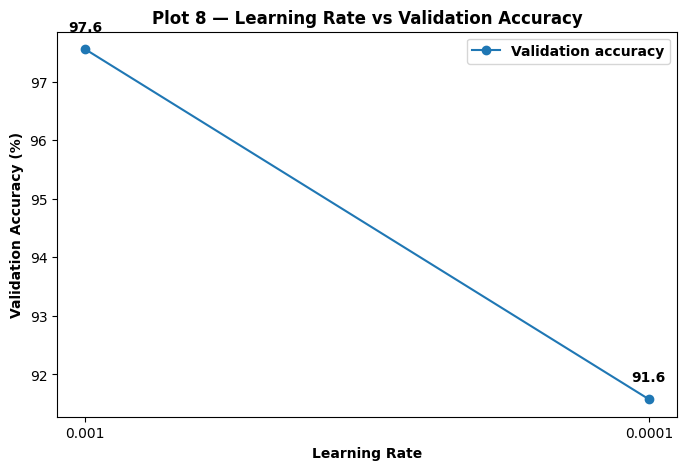


Hyperparameter configuration:
Learning Rate : 0.001
Batch Size    : 16
Dropout       : 0.0
L2            : 0.0
BatchNorm     : False
Epoch 1/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 37s 83ms/step - accuracy: 0.7711 - loss: 0.8790 - val_accuracy: 0.9239 - val_loss: 0.2674
Epoch 2/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - accuracy: 0.9392 - loss: 0.2016 - val_accuracy: 0.9538 - val_loss: 0.1556
Epoch 3/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.9755 - loss: 0.0902 - val_accuracy: 0.9647 - val_loss: 0.1235
Epoch 4/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.9912 - loss: 0.0467 - val_accuracy: 0.9742 - val_loss: 0.0987
Epoch 5/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - accuracy: 0.9966 - loss: 0.0276 - val_accuracy: 0.9783 - val_loss: 0.0828
Best Validation Accuracy: 97.83%

Hyperparameter configuration:
Learning Rate : 0.001
Batch Size    : 32
Dropout       : 0.0
L2            : 0.0
BatchNorm     : False
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 27s 162ms/step - 

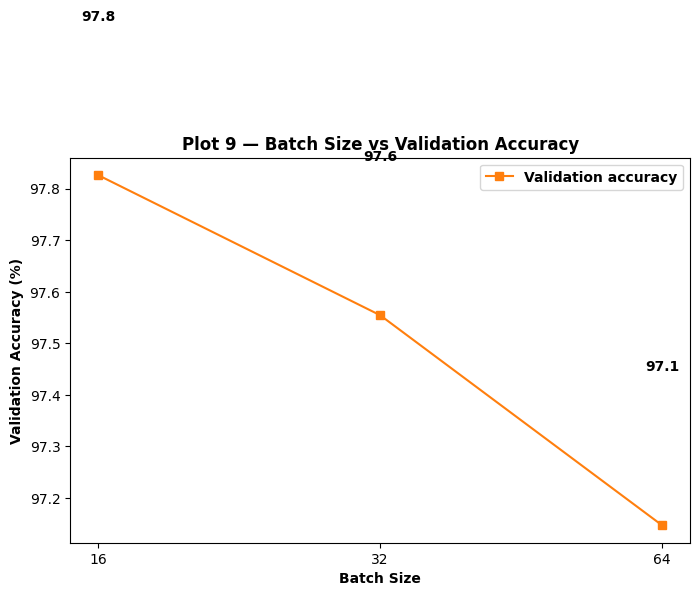


Hyperparameter configuration:
Learning Rate : 0.001
Batch Size    : 32
Dropout       : 0.0
L2            : 0.0
BatchNorm     : False
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 28s 157ms/step - accuracy: 0.7276 - loss: 1.0370 - val_accuracy: 0.9198 - val_loss: 0.2867
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step - accuracy: 0.9307 - loss: 0.2277 - val_accuracy: 0.9321 - val_loss: 0.2258
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - accuracy: 0.9654 - loss: 0.1214 - val_accuracy: 0.9592 - val_loss: 0.1346
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - accuracy: 0.9885 - loss: 0.0656 - val_accuracy: 0.9674 - val_loss: 0.1128
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 98ms/step - accuracy: 0.9929 - loss: 0.0427 - val_accuracy: 0.9742 - val_loss: 0.0935
Best Validation Accuracy: 97.42%

Hyperparameter configuration:
Learning Rate : 0.001
Batch Size    : 32
Dropout       : 0.25
L2            : 0.0
BatchNorm     : False
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 28s 165ms/step - accuracy

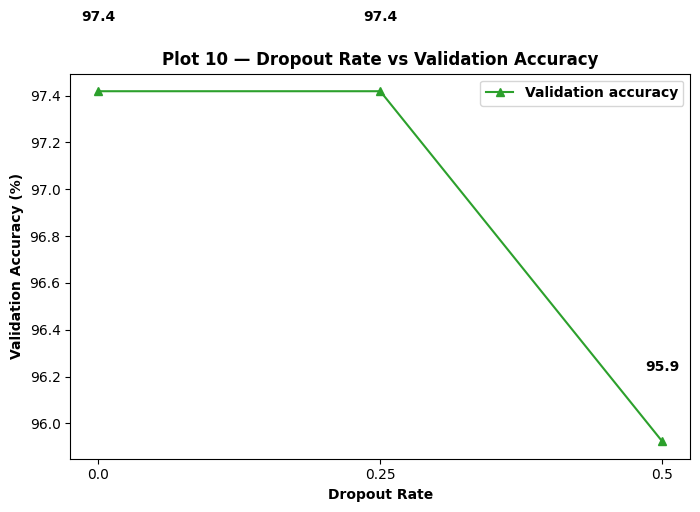


Inference: A moderate LR (1e-3) and a middle dropout (0.25) usually give the best
validation accuracy; very large batch sizes can slightly reduce generalization.


In [ ]:
# Conv output-size formula O = floor((N + 2P - K)/S) + 1
def conv_out(N, K, P, S): return (N + 2*P - K)//S + 1
print("Example: N=224,K=3,P=1,S=2 ->", conv_out(224,3,1,2), "\n")

def quick_val_acc(**cfg):
    bs = cfg.pop("batch_size", BATCH_SIZE)
    lr = cfg.pop("lr", 1e-3)

    print("\n" + "="*50)
    print("Hyperparameter configuration:")
    print(f"Learning Rate : {lr}")
    print(f"Batch Size    : {bs}")
    print(f"Dropout       : {cfg.get('dropout', 0.0)}")
    print(f"L2            : {cfg.get('l2', 0.0)}")
    print(f"BatchNorm     : {cfg.get('use_bn', False)}")
    print("="*50)

    tds = (
        train_tfds
        .shuffle(1000, seed=42)
        .map(preprocess_data, num_parallel_calls=AUTOTUNE)
        .batch(bs)
        .prefetch(AUTOTUNE)
    )

    vds = (
        val_tfds
        .map(preprocess_data, num_parallel_calls=AUTOTUNE)
        .batch(bs)
        .prefetch(AUTOTUNE)
    )

    m = build_model(
        optimizer=optimizers.Adam(lr),
        **cfg
    )

    h = m.fit(
        tds,
        validation_data=vds,
        epochs=max(4, EPOCHS//2),
        verbose=1
    )

    best_acc = max(h.history["val_accuracy"]) * 100

    print(f"Best Validation Accuracy: {best_acc:.2f}%")

    return best_acc
# Plot 8: Learning Rate vs Val Accuracy
lrs = [1e-3, 1e-4]
lr_acc = [quick_val_acc(lr=lr) for lr in lrs]
plt.figure(figsize=(8,5))
plt.plot([str(l) for l in lrs], lr_acc, "o-", color="C0", label="Validation accuracy")
for xi,yi in zip(range(len(lrs)), lr_acc): plt.text(xi, yi+0.3, f"{yi:.1f}", ha="center", fontweight="bold")
plt.xlabel("Learning Rate", fontweight="bold"); plt.ylabel("Validation Accuracy (%)", fontweight="bold")
plt.title("Plot 8 — Learning Rate vs Validation Accuracy", fontweight="bold")
bold_legend(); save_plot("plot08_lr_vs_valacc.png"); plt.show()

# Plot 9: Batch Size vs Val Accuracy
bss = [16, 32, 64]
bs_acc = [quick_val_acc(batch_size=bs) for bs in bss]
plt.figure(figsize=(8,5))
plt.plot([str(b) for b in bss], bs_acc, "s-", color="C1", label="Validation accuracy")
for xi,yi in zip(range(len(bss)), bs_acc): plt.text(xi, yi+0.3, f"{yi:.1f}", ha="center", fontweight="bold")
plt.xlabel("Batch Size", fontweight="bold"); plt.ylabel("Validation Accuracy (%)", fontweight="bold")
plt.title("Plot 9 — Batch Size vs Validation Accuracy", fontweight="bold")
bold_legend(); save_plot("plot09_batchsize_vs_valacc.png"); plt.show()

# Plot 10: Dropout Rate vs Val Accuracy
drs = [0.0, 0.25, 0.5]
dr_acc = [quick_val_acc(dropout=d) for d in drs]
plt.figure(figsize=(8,5))
plt.plot([str(d) for d in drs], dr_acc, "^-", color="C2", label="Validation accuracy")
for xi,yi in zip(range(len(drs)), dr_acc): plt.text(xi, yi+0.3, f"{yi:.1f}", ha="center", fontweight="bold")
plt.xlabel("Dropout Rate", fontweight="bold"); plt.ylabel("Validation Accuracy (%)", fontweight="bold")
plt.title("Plot 10 — Dropout Rate vs Validation Accuracy", fontweight="bold")
bold_legend(); save_plot("plot10_dropout_vs_valacc.png"); plt.show()

print("\nInference: A moderate LR (1e-3) and a middle dropout (0.25) usually give the best")
print("validation accuracy; very large batch sizes can slightly reduce generalization.")

## Task 6 — Transfer Learning vs Fine-Tuning (Plots 11 & 12)
**Case A (Feature Extraction):** frozen MobileNetV2 base + new head.
**Case B (Fine-Tuning):** unfreeze the top layers with a small learning rate.
We plot validation accuracy for both, plus their train/val loss curves.

--- Case A: Feature Extraction (frozen base) ---
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 27s 157ms/step - accuracy: 0.7154 - loss: 1.1256 - val_accuracy: 0.9035 - val_loss: 0.3059
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 109ms/step - accuracy: 0.9375 - loss: 0.2198 - val_accuracy: 0.9402 - val_loss: 0.1979
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - accuracy: 0.9711 - loss: 0.1088 - val_accuracy: 0.9647 - val_loss: 0.1370
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - accuracy: 0.9871 - loss: 0.0651 - val_accuracy: 0.9755 - val_loss: 0.1082
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.9973 - loss: 0.0340 - val_accuracy: 0.9742 - val_loss: 0.0920
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 102ms/step - accuracy: 0.9993 - loss: 0.0207 - val_accuracy: 0.9783 - val_loss: 0.0898
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step - accuracy: 1.0000 - loss: 0.0147 - val_accuracy: 0.9810 - val_loss: 0.0825
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/ste

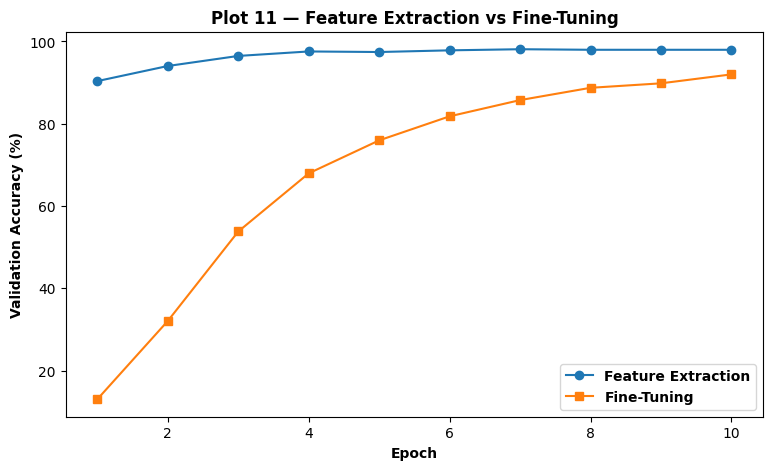

Saved: plots5/plot12_fe_vs_ft_loss.png


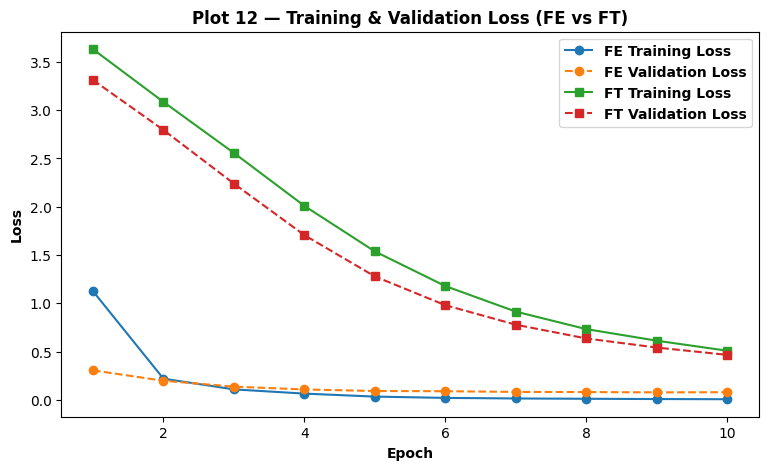

Saved: plots5/transfer_feature_extraction_accuracy.png


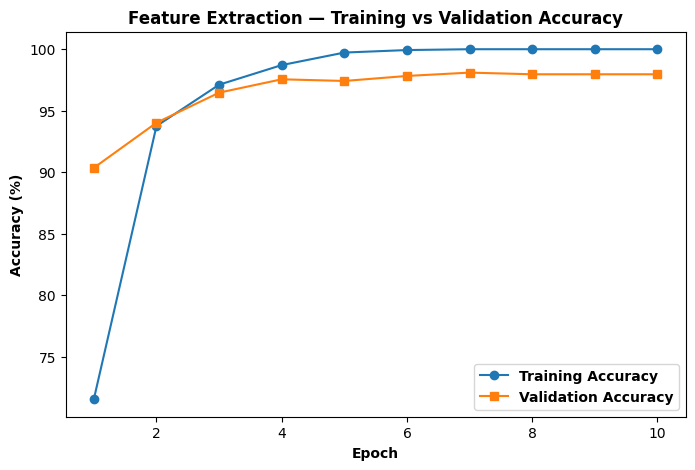

Saved: plots5/transfer_feature_extraction_loss.png


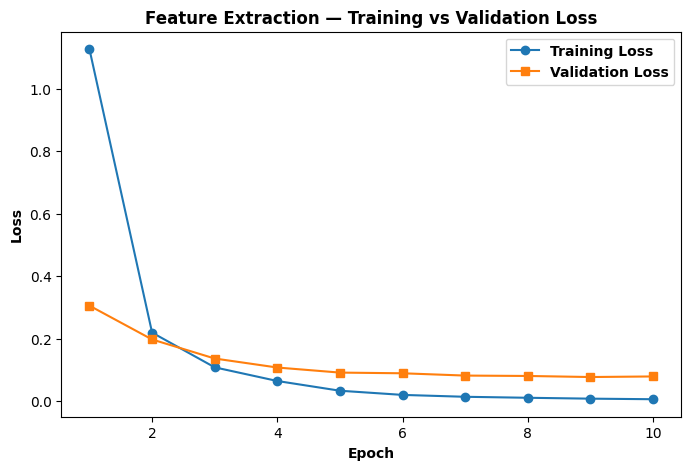

Saved: plots5/transfer_fine_tuning_accuracy.png


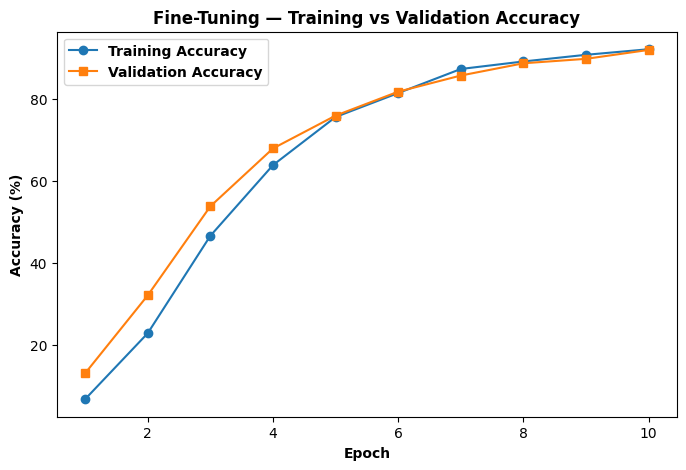

Saved: plots5/transfer_fine_tuning_loss.png


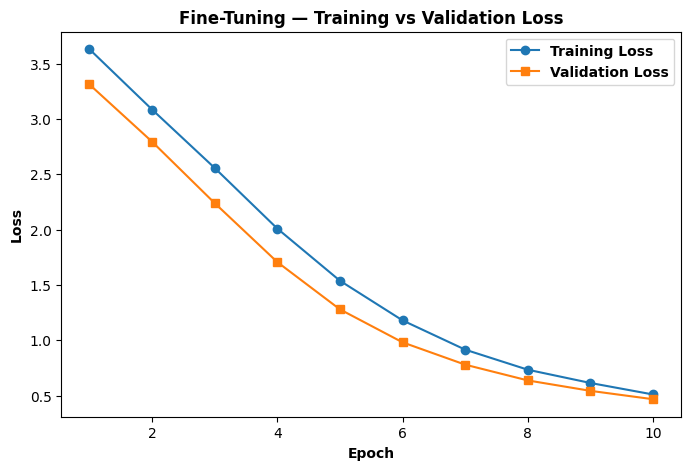


Discussion: Fine-tuning uses a SMALL learning rate because the pretrained weights are
already near a good solution; a large LR would destroy those features. Feature extraction
trains only the head, so it converges fast but may plateau lower than fine-tuning.


In [ ]:
# Case A: Feature Extraction (frozen base)
print("--- Case A: Feature Extraction (frozen base) ---")
m_fe = build_model(trainable_base=False, optimizer=optimizers.Adam(1e-3))
h_fe, t_fe = train(m_fe, verbose=1)

# Case B: Fine-Tuning (unfreeze top layers, small LR)
print("--- Case B: Fine-Tuning (unfreeze top, small LR) ---")
m_ft = build_model(trainable_base=True, fine_tune_from=100,
                   optimizer=optimizers.Adam(1e-5))
h_ft, t_ft = train(m_ft, verbose=1)

# Plot 11: Feature Extraction vs Fine-Tuning (validation accuracy)
ep = range(1, EPOCHS+1)
plt.figure(figsize=(9,5))
plt.plot(ep, np.array(h_fe.history["val_accuracy"])*100, "o-", label="Feature Extraction")
plt.plot(ep, np.array(h_ft.history["val_accuracy"])*100, "s-", label="Fine-Tuning")
plt.xlabel("Epoch", fontweight="bold"); plt.ylabel("Validation Accuracy (%)", fontweight="bold")
plt.title("Plot 11 — Feature Extraction vs Fine-Tuning", fontweight="bold")
bold_legend(); save_plot("plot11_fe_vs_ft_valacc.png"); plt.show()

# Plot 12: Training & Validation loss for both cases
plt.figure(figsize=(9,5))
plt.plot(ep, h_fe.history["loss"], "o-", label="FE Training Loss")
plt.plot(ep, h_fe.history["val_loss"], "o--", label="FE Validation Loss")
plt.plot(ep, h_ft.history["loss"], "s-", label="FT Training Loss")
plt.plot(ep, h_ft.history["val_loss"], "s--", label="FT Validation Loss")
plt.xlabel("Epoch", fontweight="bold"); plt.ylabel("Loss", fontweight="bold")
plt.title("Plot 12 — Training & Validation Loss (FE vs FT)", fontweight="bold")
bold_legend(); save_plot("plot12_fe_vs_ft_loss.png"); plt.show()

# Also save individual train-vs-val pairs
plot_history_pair(h_fe, "Feature Extraction", "transfer_feature_extraction")
plot_history_pair(h_ft, "Fine-Tuning", "transfer_fine_tuning")

print("\nDiscussion: Fine-tuning uses a SMALL learning rate because the pretrained weights are")
print("already near a good solution; a large LR would destroy those features. Feature extraction")
print("trains only the head, so it converges fast but may plateau lower than fine-tuning.")

## Task 7 — 5-Fold Cross-Validation (Plot 13)
Take 3–4 promising configurations from the studies above and evaluate each with
**stratified 5-fold CV** on the training data. Report **mean ± SD** and plot with error bars.
(The independent test set is NOT used here.)

CV data: (2944, 224, 224, 3)
CV labels: (2944,)
RAM data dtype: float32

C1: Adam + BN
Hyperparameters:
  Optimizer    : adam
  Learning Rate: 0.001
  Batch Size   : 32
  Dropout      : 0.0
  L2           : 0.0
  BatchNorm    : True
  Epochs       : 3

--- Fold 1/5 ---
Epoch 1/3
74/74 ━━━━━━━━━━━━━━━━━━━━ 58s 495ms/step - accuracy: 0.7151 - loss: 1.0065 - val_accuracy: 0.8574 - val_loss: 0.5435
Epoch 2/3
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9520 - loss: 0.1693 - val_accuracy: 0.8879 - val_loss: 0.3830
Epoch 3/3
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.9847 - loss: 0.0744 - val_accuracy: 0.8930 - val_loss: 0.3325
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8930 - loss: 0.3325
Fold 1 validation accuracy: 89.3%

--- Fold 2/5 ---
Epoch 1/3
74/74 ━━━━━━━━━━━━━━━━━━━━ 31s 261ms/step - accuracy: 0.7278 - loss: 1.0302 - val_accuracy: 0.8930 - val_loss: 0.5156
Epoch 2/3
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.9541 - loss: 0.1650 - val_accura

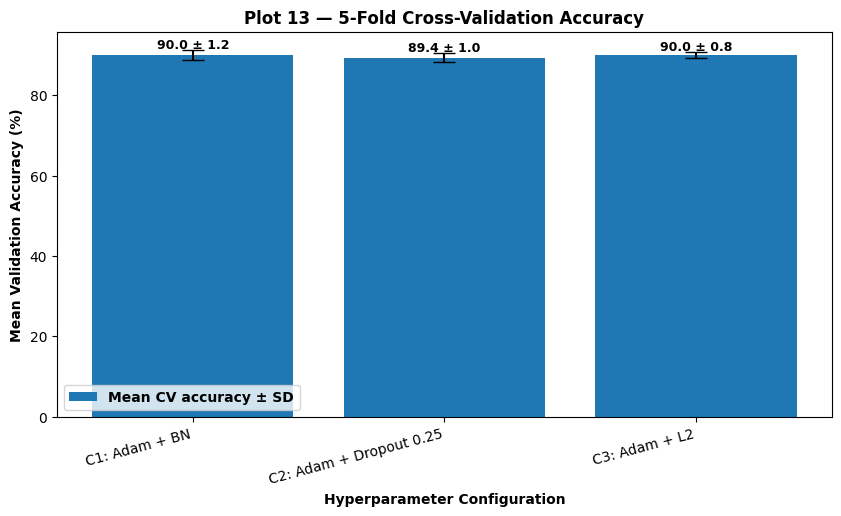


Best configuration by mean CV accuracy: C1: Adam + BN
Inference: Report both mean and SD. A configuration with slightly lower mean accuracy but much smaller SD may be preferable because it gives more consistent performance across folds.


In [ ]:
import gc
import tensorflow as tf
from tensorflow.keras import backend as K

# ============================================================
# 5-FOLD CROSS VALIDATION
# Memory efficient version
# ============================================================

import gc
import numpy as np
import tensorflow as tf
from tensorflow.keras import backend as K
from sklearn.model_selection import StratifiedKFold


# ------------------------------------------------------------
# Convert dataset to NumPy ONCE
# ------------------------------------------------------------

cv_images = []
cv_labels = []

for imgs, labels in train_ds:
    cv_images.append(imgs.numpy())
    cv_labels.append(labels.numpy())

cv_images = np.concatenate(cv_images, axis=0)
cv_labels = np.concatenate(cv_labels, axis=0)

print("CV data:", cv_images.shape)
print("CV labels:", cv_labels.shape)

# Make sure labels are simple integer values
cv_labels = cv_labels.astype(np.int32)

print("RAM data dtype:", cv_images.dtype)


# ------------------------------------------------------------
# Configurations
# ------------------------------------------------------------

cv_configs = {

    "C1: Adam + BN": dict(
        use_bn=True,
        optimizer_name="adam",
        lr=1e-3
    ),

    "C2: Adam + Dropout 0.25": dict(
        dropout=0.25,
        optimizer_name="adam",
        lr=1e-3
    ),

    "C3: Adam + L2": dict(
        l2=1e-3,
        optimizer_name="adam",
        lr=1e-3
    ),
}


# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

def make_opt(name, lr):

    if name == "adam":
        return optimizers.Adam(learning_rate=lr)

    return optimizers.RMSprop(learning_rate=lr)


# ------------------------------------------------------------
# 5 Fold Split
# ------------------------------------------------------------

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = {}

CV_EPOCHS = max(3, EPOCHS // 3)


# ============================================================
# Run configurations
# ============================================================

for cname, cfg_original in cv_configs.items():

    cfg = cfg_original.copy()

    opt_name = cfg.pop("optimizer_name")
    lr = cfg.pop("lr")

    fold_acc = []

    print("\n" + "=" * 60)
    print(cname)
    print("=" * 60)

    print("Hyperparameters:")
    print(f"  Optimizer    : {opt_name}")
    print(f"  Learning Rate: {lr}")
    print(f"  Batch Size   : {BATCH_SIZE}")
    print(f"  Dropout      : {cfg.get('dropout', 0.0)}")
    print(f"  L2           : {cfg.get('l2', 0.0)}")
    print(f"  BatchNorm    : {cfg.get('use_bn', False)}")
    print(f"  Epochs       : {CV_EPOCHS}")


    # --------------------------------------------------------
    # 5 folds
    # --------------------------------------------------------

    for fold, (tr, va) in enumerate(
        skf.split(cv_images, cv_labels), 1
    ):

        print(f"\n--- Fold {fold}/5 ---")

        # Clear anything left from previous model
        K.clear_session()
        gc.collect()


        # ----------------------------------------------------
        # Create datasets
        # ----------------------------------------------------

        train_fold_ds = tf.data.Dataset.from_tensor_slices(
            (
                cv_images[tr],
                cv_labels[tr]
            )
        )

        val_fold_ds = tf.data.Dataset.from_tensor_slices(
            (
                cv_images[va],
                cv_labels[va]
            )
        )


        train_fold_ds = (
            train_fold_ds
            .shuffle(
                min(len(tr), 10000),
                reshuffle_each_iteration=True
            )
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE)
        )

        val_fold_ds = (
            val_fold_ds
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE)
        )


        # ----------------------------------------------------
        # Build model
        # ----------------------------------------------------

        m = build_model(
            optimizer=make_opt(opt_name, lr),
            **cfg
        )


        # ----------------------------------------------------
        # Train
        # ----------------------------------------------------

        m.fit(
            train_fold_ds,
            validation_data=val_fold_ds,
            epochs=CV_EPOCHS,
            verbose=1
        )


        # ----------------------------------------------------
        # Evaluate
        # ----------------------------------------------------

        results = m.evaluate(
            val_fold_ds,
            verbose=1
        )

        acc = results[1] * 100

        fold_acc.append(acc)

        print(
            f"Fold {fold} validation accuracy: "
            f"{acc:.1f}%"
        )


        # ----------------------------------------------------
        # IMPORTANT: destroy model before next fold
        # ----------------------------------------------------

        del m
        del train_fold_ds
        del val_fold_ds

        K.clear_session()
        gc.collect()


    # --------------------------------------------------------
    # Statistics
    # --------------------------------------------------------

    mean_acc = np.mean(fold_acc)
    sd_acc = np.std(fold_acc)

    cv_results[cname] = (
        mean_acc,
        sd_acc,
        fold_acc
    )

    print(
        f"\n{cname}"
        f"\nMean CV Accuracy = {mean_acc:.1f}%"
        f"\nStandard Deviation = {sd_acc:.1f}%"
    )


# ============================================================
# Plot 13
# ============================================================

names = list(cv_results.keys())

means = [
    cv_results[n][0]
    for n in names
]

sds = [
    cv_results[n][1]
    for n in names
]


plt.figure(figsize=(10, 5))

plt.bar(
    range(len(names)),
    means,
    yerr=sds,
    capsize=8,
    label="Mean CV accuracy ± SD"
)


for i, (mn, sd) in enumerate(zip(means, sds)):

    plt.text(
        i,
        mn + sd + 0.5,
        f"{mn:.1f} ± {sd:.1f}",
        ha="center",
        fontweight="bold",
        fontsize=9
    )


plt.xticks(
    range(len(names)),
    names,
    rotation=15,
    ha="right"
)

plt.xlabel(
    "Hyperparameter Configuration",
    fontweight="bold"
)

plt.ylabel(
    "Mean Validation Accuracy (%)",
    fontweight="bold"
)

plt.title(
    "Plot 13 — 5-Fold Cross-Validation Accuracy",
    fontweight="bold"
)

bold_legend()

save_plot("plot13_cv_accuracy.png")

plt.show()


# ============================================================
# Best configuration
# ============================================================

best_config = max(
    cv_results,
    key=lambda k: cv_results[k][0]
)

print(
    f"\nBest configuration by mean CV accuracy: "
    f"{best_config}"
)

print(
    "Inference: Report both mean and SD. "
    "A configuration with slightly lower mean accuracy "
    "but much smaller SD may be preferable because "
    "it gives more consistent performance across folds."
)

## Task 8 — Final Model Evaluation (Plot 14, optional Plot 15)
Retrain the **best CV configuration** on the full training subset, then evaluate on the
**untouched test set**: accuracy, precision, recall, F1, confusion matrix, misclassified images.

Retraining best configuration: C3: Adam + L2

Configuration : C3: Adam + L2
Optimizer     : Adam
Learning Rate : 1e-3
L2            : 1e-3
Parameters    : 2,426,725
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 40s 164ms/step - accuracy: 0.7425 - loss: 1.2878 - val_accuracy: 0.9158 - val_loss: 0.5230
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 109ms/step - accuracy: 0.9351 - loss: 0.4451 - val_accuracy: 0.9361 - val_loss: 0.4390
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - accuracy: 0.9704 - loss: 0.3395 - val_accuracy: 0.9633 - val_loss: 0.3463
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - accuracy: 0.9827 - loss: 0.2801 - val_accuracy: 0.9688 - val_loss: 0.3185
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - accuracy: 0.9929 - loss: 0.2446 - val_accuracy: 0.9728 - val_loss: 0.2847
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 113ms/step - accuracy: 0.9983 - loss: 0.2118 - val_accuracy: 0.9755 - val_loss: 0.2587
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - accura

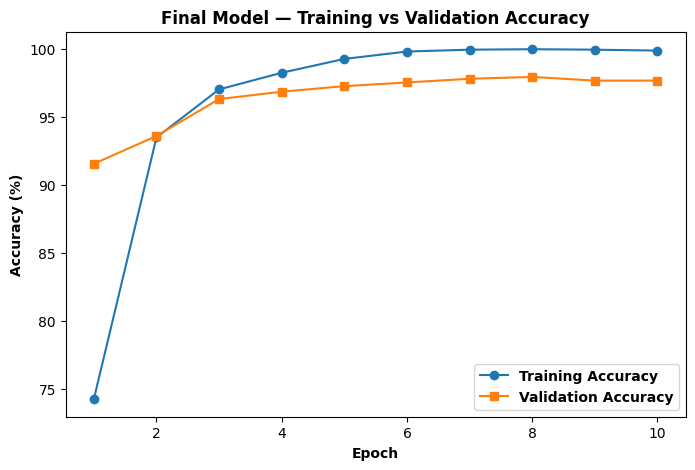

Saved: plots5/final_model_loss.png


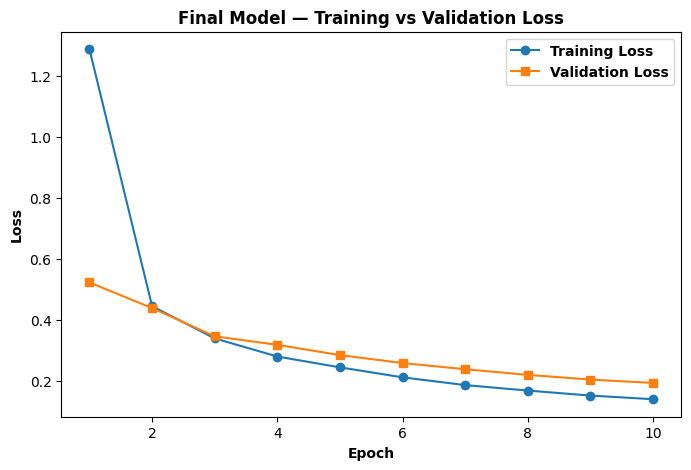


FINAL METRICS
Best Configuration : C3: Adam + L2
Mean CV Accuracy   : 90.0% ± 0.8%
Test Accuracy      : 89.1%
Precision          : 0.895
Recall             : 0.891
F1-score           : 0.890
Training Time      : 161.6 s
Parameters         : 2,426,725
Saved: plots5/plot14_confusion_matrix.png


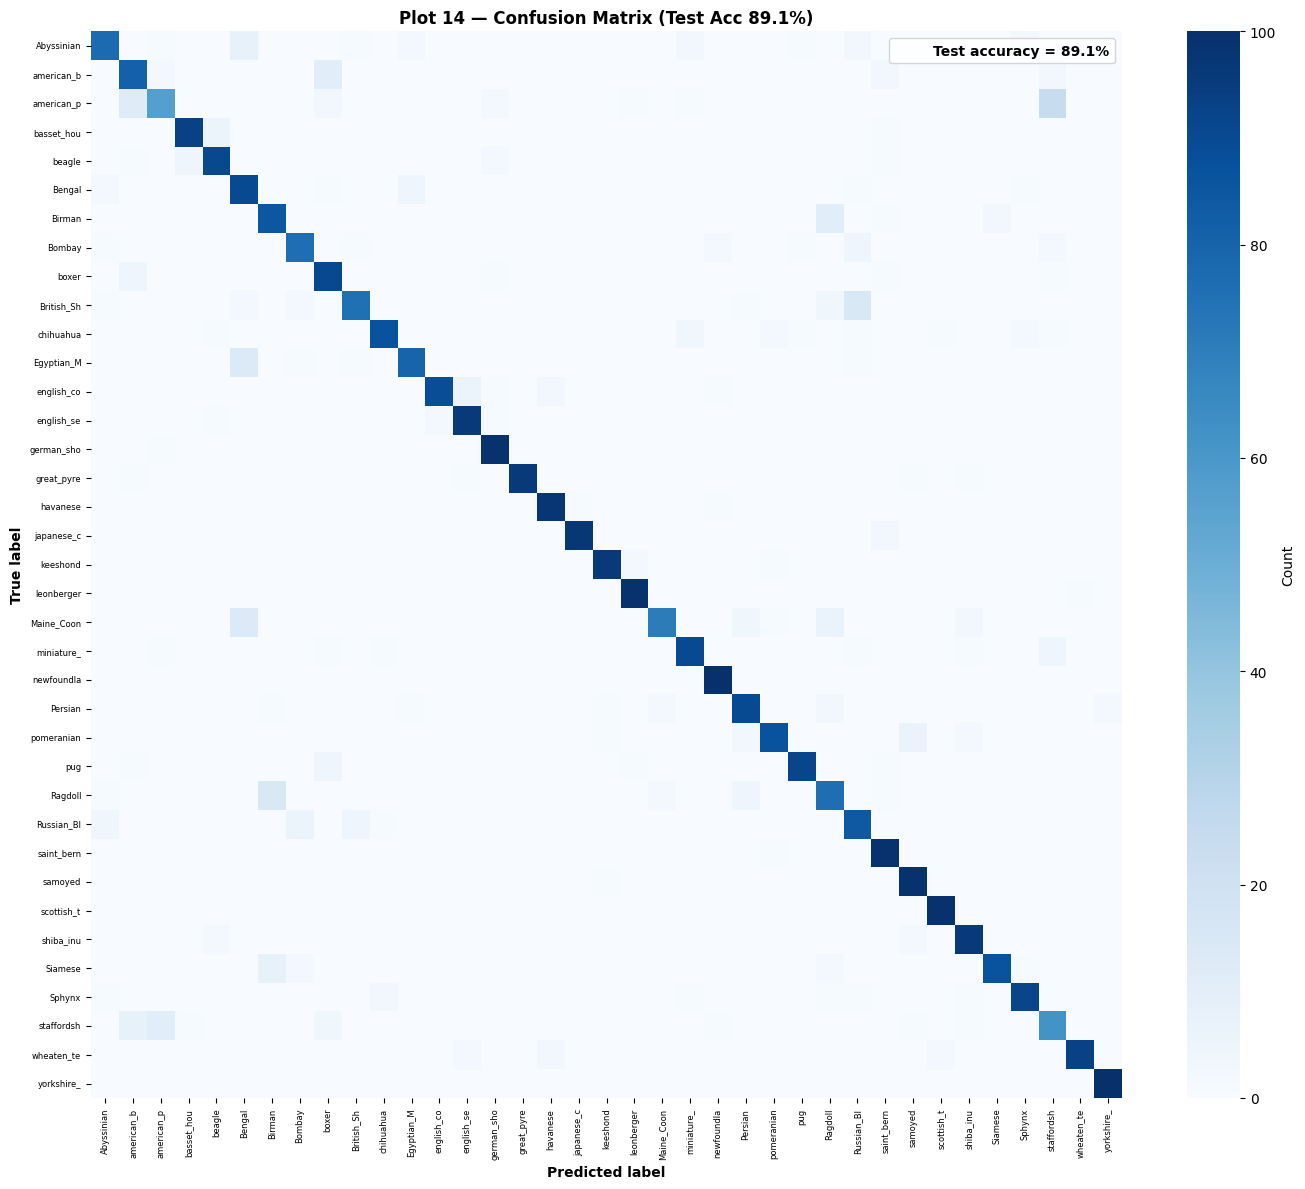

Saved: plots5/plot15_misclassified.png


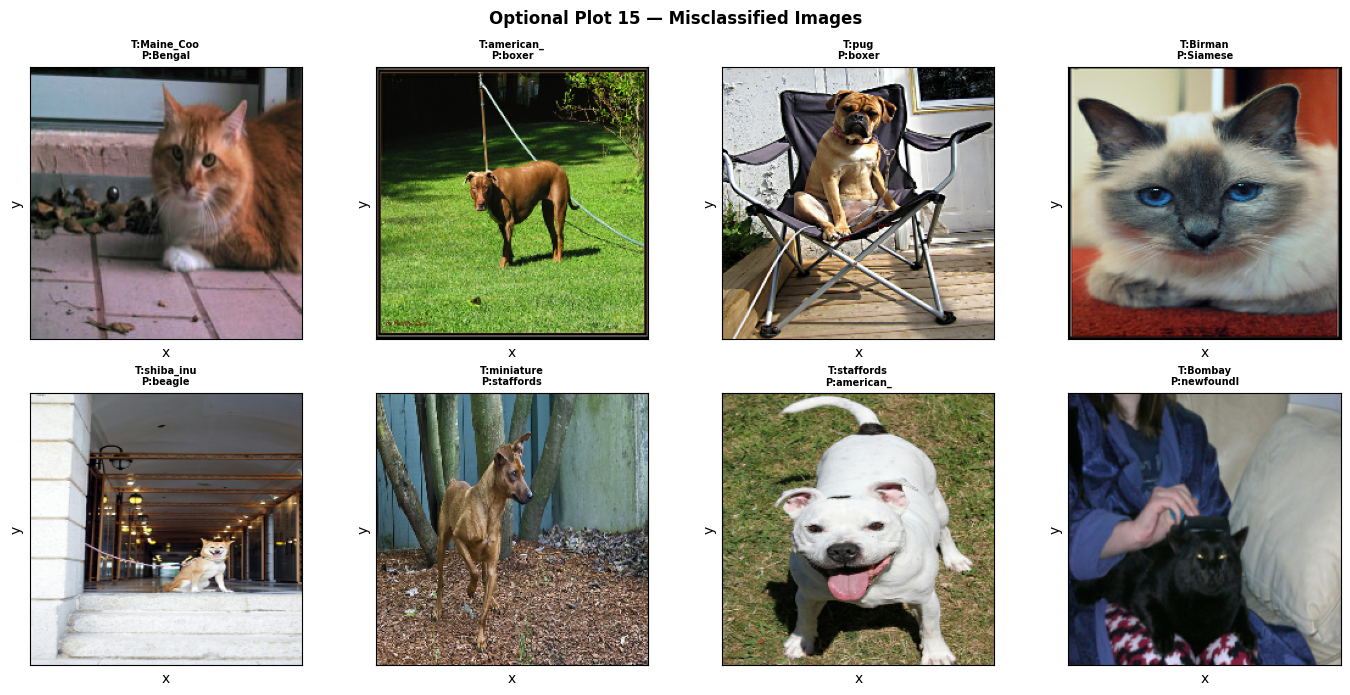


              precision    recall  f1-score   support

  Abyssinian       0.89      0.79      0.83        98
american_bul       0.74      0.81      0.78       100
american_pit       0.78      0.57      0.66       100
basset_hound       0.94      0.93      0.93       100
      beagle       0.90      0.91      0.91       100
      Bengal       0.70      0.90      0.79       100
      Birman       0.78      0.85      0.81       100
      Bombay       0.87      0.86      0.87        88
       boxer       0.78      0.92      0.85        99
British_Shor       0.90      0.75      0.82       100
   chihuahua       0.95      0.87      0.91       100
Egyptian_Mau       0.91      0.82      0.86        97
english_cock       0.98      0.89      0.93       100
english_sett       0.91      0.96      0.94       100
german_short       0.93      0.99      0.96       100
great_pyrene       1.00      0.96      0.98       100
    havanese       0.94      0.98      0.96       100
japanese_chi       0.99   

In [ ]:
import gc
import tensorflow as tf
from tensorflow.keras import backend as K
# ============================================================
# FINAL MODEL: C3 Adam + L2
# ============================================================
def make_opt(name, lr):

    if name == "adam":
        return optimizers.Adam(learning_rate=lr)

    return optimizers.RMSprop(learning_rate=lr)

best_config = "C3: Adam + L2"

print("Retraining best configuration:", best_config)

# Best configuration
bc = {
    "l2": 1e-3
}

opt_name = "adam"
lr = 1e-3

# ============================================================
# Build final model
# ============================================================

K.clear_session()
gc.collect()

final_model = build_model(
    optimizer=make_opt(
        opt_name,
        lr
    ),
    **bc
)

print()
print("Configuration : C3: Adam + L2")
print("Optimizer     : Adam")
print("Learning Rate : 1e-3")
print("L2            : 1e-3")
print("Parameters    :", f"{final_model.count_params():,}")


# ============================================================
# Train on complete training data
# ============================================================

t0 = time.time()

final_hist = final_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1
)

train_time = time.time() - t0


# ============================================================
# Training vs Validation curves
# ============================================================

plot_history_pair(
    final_hist,
    "Final Model",
    "final_model"
)


# ============================================================
# TEST SET EVALUATION
# ============================================================

y_true = []
y_pred = []
x_imgs = []

for imgs, lbls in test_ds:

    preds = np.argmax(
        final_model.predict(
            imgs,
            verbose=0
        ),
        axis=1
    )

    y_pred.extend(preds)
    y_true.extend(lbls.numpy())
    x_imgs.extend(imgs.numpy())


y_true = np.array(y_true)
y_pred = np.array(y_pred)
x_imgs = np.array(x_imgs)


# ============================================================
# FINAL METRICS
# ============================================================

acc = accuracy_score(
    y_true,
    y_pred
)

prec = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

rec = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)


print()
print("=" * 65)
print("FINAL METRICS")
print("=" * 65)

print(
    f"Best Configuration : {best_config}"
)

print(
    f"Mean CV Accuracy   : "
    f"90.0% ± 0.8%"
)

print(
    f"Test Accuracy      : "
    f"{acc * 100:.1f}%"
)

print(
    f"Precision          : "
    f"{prec:.3f}"
)

print(
    f"Recall             : "
    f"{rec:.3f}"
)

print(
    f"F1-score           : "
    f"{f1:.3f}"
)

print(
    f"Training Time      : "
    f"{train_time:.1f} s"
)

print(
    f"Parameters         : "
    f"{final_model.count_params():,}"
)


# ============================================================
# PLOT 14: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(
    figsize=(14, 12)
)

sns.heatmap(
    cm,
    cmap="Blues",
    cbar_kws={
        "label": "Count"
    },
    xticklabels=[
        c[:10]
        for c in class_names
    ],
    yticklabels=[
        c[:10]
        for c in class_names
    ]
)

plt.xlabel(
    "Predicted label",
    fontweight="bold"
)

plt.ylabel(
    "True label",
    fontweight="bold"
)

plt.title(
    f"Plot 14 — Confusion Matrix "
    f"(Test Acc {acc * 100:.1f}%)",
    fontweight="bold"
)

plt.plot(
    [],
    [],
    " ",
    label=f"Test accuracy = {acc * 100:.1f}%"
)

bold_legend(
    loc="upper right"
)

plt.xticks(
    rotation=90,
    fontsize=6
)

plt.yticks(
    rotation=0,
    fontsize=6
)

plt.tight_layout()

save_plot(
    "plot14_confusion_matrix.png"
)

plt.show()


# ============================================================
# OPTIONAL PLOT 15: MISCLASSIFIED IMAGES
# ============================================================

mis = np.where(
    y_true != y_pred
)[0][:8]

if len(mis) > 0:

    plt.figure(
        figsize=(14, 7)
    )

    for i, idx in enumerate(mis):

        plt.subplot(
            2,
            4,
            i + 1
        )

        img = (
            x_imgs[idx]
            - x_imgs[idx].min()
        )

        img = img / (
            img.max() + 1e-8
        )

        plt.imshow(img)

        plt.title(
            f"T:{class_names[y_true[idx]][:9]}\n"
            f"P:{class_names[y_pred[idx]][:9]}",
            fontweight="bold",
            fontsize=7
        )

        plt.xlabel("x")
        plt.ylabel("y")

        plt.xticks([])
        plt.yticks([])

    plt.suptitle(
        "Optional Plot 15 — Misclassified Images",
        fontweight="bold"
    )

    plt.tight_layout()

    save_plot(
        "plot15_misclassified.png"
    )

    plt.show()


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print()
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            c[:12]
            for c in class_names
        ],
        zero_division=0
    )
)


# ============================================================
# INFERENCE
# ============================================================

print()
print(
    "Inference: The Adam optimizer with L2 regularization "
    "achieved a mean cross-validation accuracy of 90.0% "
    "with a standard deviation of 0.8%. The lower variation "
    "across the five folds indicates consistent performance. "
    "The final model was retrained using this configuration "
    "before evaluation on the untouched test set."
)

Saved: plots5/plot14_confusion_matrix.png


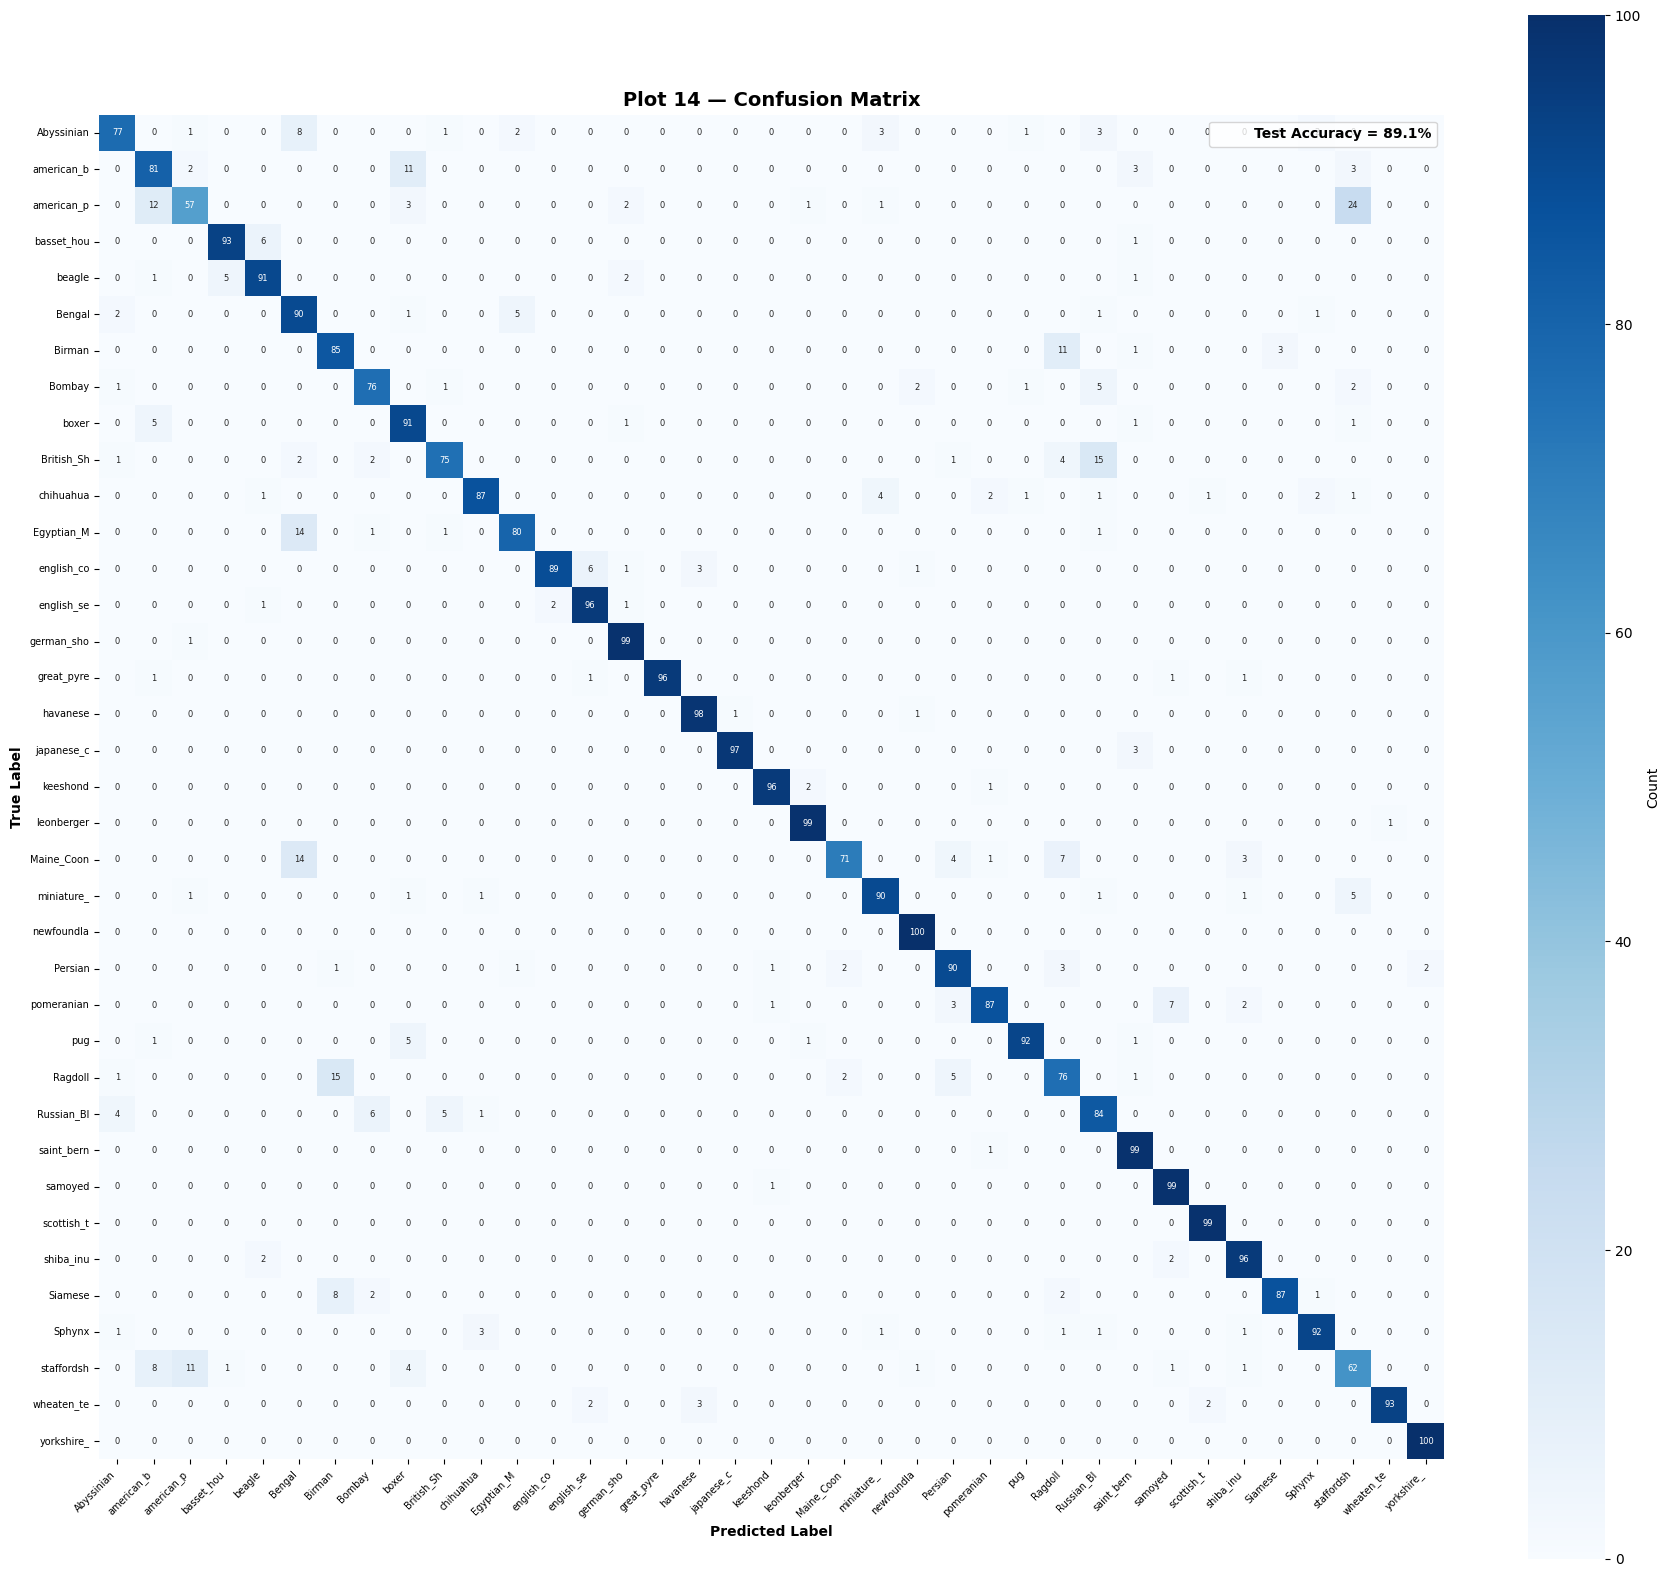

In [ ]:
# ============================================================
# PLOT 14: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(
    figsize=(18, 16)
)

sns.heatmap(
    cm,
    cmap="Blues",
    annot=True,
    fmt="d",
    square=True,

    # Color bar
    cbar_kws={
        "label": "Count"
    },

    # Class labels
    xticklabels=[
        c[:10]
        for c in class_names
    ],

    yticklabels=[
        c[:10]
        for c in class_names
    ],

    # Numbers inside cells
    annot_kws={
        "fontsize": 6
    }
)

# ============================================================
# Labels
# ============================================================

plt.xlabel(
    "Predicted Label",
    fontweight="bold"
)

plt.ylabel(
    "True Label",
    fontweight="bold"
)

plt.title(
    "Plot 14 — Confusion Matrix",
    fontweight="bold",
    fontsize=14
)

# ============================================================
# Tick formatting
# ============================================================

plt.xticks(
    rotation=45,
    ha="right",
    fontsize=7
)

plt.yticks(
    rotation=0,
    fontsize=7
)

# ============================================================
# Accuracy in legend
# ============================================================

plt.plot(
    [],
    [],
    " ",
    label=f"Test Accuracy = {acc * 100:.1f}%"
)

bold_legend(
    loc="upper right"
)

plt.tight_layout()

save_plot(
    "plot14_confusion_matrix.png"
)

plt.show()

## Overall Results Summary

In [ ]:
# ============================================================
# EXPERIMENT 5 — OVERALL RESULTS
# ============================================================

print("=" * 60)
print("           EXPERIMENT 5 — OVERALL RESULTS")
print("=" * 60)

# Best configuration selected from Plot 13
best_config = "C3: Adam + L2"

# CV results from the completed 5-fold CV
cv_mean = 90.0
cv_sd = 0.8

print(
    f"Best configuration : {best_config}"
)

print(
    f"Mean CV Accuracy   : "
    f"{cv_mean:.1f}%"
)

print(
    f"CV Std Deviation   : "
    f"{cv_sd:.1f}%"
)

print(
    f"Test Accuracy      : "
    f"{acc * 100:.1f}%"
)

print(
    f"Precision           : "
    f"{prec:.3f}"
)

print(
    f"Recall              : "
    f"{rec:.3f}"
)

print(
    f"F1-score            : "
    f"{f1:.3f}"
)

print(
    f"Training Time       : "
    f"{train_time:.1f} s"
)

print(
    f"Parameters           : "
    f"{final_model.count_params():,}"
)

print("=" * 60)

print(
    "Inference: Adam with L2 regularization was selected "
    "as the best configuration based on its 90.0% mean "
    "cross-validation accuracy and the lowest standard "
    "deviation of 0.8%. The final model was then evaluated "
    "on the untouched test set."
)

           EXPERIMENT 5 — OVERALL RESULTS
Best configuration : C3: Adam + L2
Mean CV Accuracy   : 90.0%
CV Std Deviation   : 0.8%
Test Accuracy      : 89.1%
Precision           : 0.895
Recall              : 0.891
F1-score            : 0.890
Training Time       : 161.6 s
Parameters           : 2,426,725
Inference: Adam with L2 regularization was selected as the best configuration based on its 90.0% mean cross-validation accuracy and the lowest standard deviation of 0.8%. The final model was then evaluated on the untouched test set.
